# Extending {spatsoc} to measure intragroup social dynamics

Alec L. Robitaille [](https://orcid.org/0000-0002-4706-1762) (Department of Biology, Memorial University of Newfoundland and Labrador)  
Quinn M. R. Webber [](https://orcid.org/0000-0002-0434-9360) (University of Guelph)  
Eric Vander Wal [](https://orcid.org/0000-0002-8534-4317) (Department of Biology, Memorial University of Newfoundland and Labrador)  
March 8, 2026

1.  Beyond proximity-based social networks and home range overlap, animal telemetry data can also be used to measure intragroup social dynamics including individual position within groups, individual and group level movement directions, leadership patterns and lagged follower behaviours.
2.  We used a scoping review of literature across domains, including behavioural ecology, collective movement, and GISciences, to identify widely used metrics for measuring intragroup social dynamics that are not openly available in the R programming language.
3.  We present a case study illustrating 18 new functions for the R package {spatsoc} measuring intragroup social dynamics with animal telemetry data.
4.  The open availability of these new and flexible functions in {spatsoc} will allow researchers to easily measure intragroup social dynamics to more comprehensively measure the multifaceted animal social behaviours in their study systems.

# Introduction

In [ ]:
targets::tar_source('_targets.R')

qs2 0.1.5


Attaching package: 'janitor'

The following objects are masked from 'package:stats':

    chisq.test, fisher.test

Linking to GEOS 3.14.1, GDAL 3.12.1, PROJ 9.7.0; sf_use_s2() is TRUE

udunits database from /usr/share/udunits/udunits2.xml

The R package {spatsoc} was developed to derive social networks from animal telemetry data using aggregated association rates, interindividual distances, and home range overlap \[@Robitaille_2019\]. These methods have been used to measure social cohesion \[@Bracken_2022\], human-wildlife conflict \[@Boudreau_2022\], socioecology and resource availability \[@Peignier_2019\], community structure \[@Sunga_2021\], the influence of stress on social proximity \[@Keshavarzi_2023\], and social patterns in non-social species \[@Heeres_2024\]. Despite these substantive and varied applications of {spatsoc}, users lacked sufficient and accessible functionality for measuring the behaviour of individuals within social groups.

Many facets of group living need to be considered to better measure animal social systems \[@King_2018\]. Beyond associations, there are additional types of dyadic relationships including genetic, affiliative, agonistic, and cooperative \[@Farine_2015\]. There are also interactions between spatial phenotypes, social phenotypes, and environments \[@Webber_2023\]. Using direct observations, researchers have studied intragroup social dynamics including social foraging \[@Barnard_1981; @Giraldeau_1986; @Hirsch_2020\], spatial position within groups \[@Krause_1994; @Monus_2008\] and the influence of individual traits such as age, sex, and dominance \[@Furuichi_1983; @King_2009; @Teichroeb_2015\]. Unfortunately, direct observations can be labour-intensive to collect and susceptible to observer bias \[@Smith_2021\], with low spatial and temporal resolution making them imperfect for studies of collective movement \[@King_2018\].

There are expanded opportunities in studying animal social systems by pairing advances in remote tracking technology with emerging methods to measure intragroup social dynamics. The availability and resolution of remote tracking data continues to improve \[@Kays_2015; @Kays_2022; @Nathan_2022\]. There are over two decades of research on measuring interactions between moving individuals from the study of “moving point objects” in GISciences \[@Andersson_2008; @Dodge_2008; @Laube_2005; @Miller_2021\] to group coordination \[@Couzin_2002; @Herbert-Read_2011\], leadership, and decision making \[@King_2011; @Nagy_2010; @Strandburg-Peshkin_2015\]. Despite this, we suggest the lack of availability of open source tools \[@Hampton_2015; @Powers_2019; @Wilson_2017\] is the missing piece between the call to integrate technology enhanced research with multidisciplinary approaches to better study animal social systems \[@Couzin_2023; @King_2018\].

We conducted a scoping review to identify metrics that were applicable to spatiotemporal data, and focused on dyadic interactions, leadership patterns, and dominance hierarchies. Of the resulting metrics, we selected those with a high evidence of use, and lack of availability in the R programming language, either through R packages or supplemental materials in the literature. Here we present 18 new functions in the R package {spatsoc} \[@Robitaille_2019\] for measuring intragroup dynamics (\[Table @tbl-new-functions\]). We will demonstrate these new functions through a case study and discuss biological interpretations.

# Methods

We conducted a scoping review to identify metrics for measuring intragroup social dynamics including dyadic interactions, leadership patterns, and dominance hierarchies. We focused on metrics applicable to spatiotemporal data such as animal movement data. This scoping review expands on the review conducted by @Joo_2018 by using interdisciplinary sources (eg. @Miller_2021), including metrics measuring group-level dynamics, leadership patterns, and lagged-follower behaviours, and by focusing on the open source availability of these metrics in the R programming language. See details scoping review methods in Supplement \[@sec-scoping-methods\]. and Metrics were selected for inclusion in {spatsoc} based on their relative importance as measured by frequency of use in the review, and their lack of availability in R packages when the review was conducted (Supplement \[@sec-scoping-results\]). Some metrics were specifically not chosen for inclusion such as metrics relating to posture, metrics relating to static interaction or home range overlap and metrics based on statistical models such as Hidden Markov model and Granger causality. A full list of metrics not selected is in Supplement \[@sec-selected\].

In [ ]:
functions <- fread('data/spatsoc-functions.tsv')
new_functions <- functions[Category == 'New']
new_functions[, .(Function, Description)] |>
  tt() |>
  group_tt(i = new_functions$Family) |>
  style_tt(align = 'l')

Function,Description
Spatial interface,Spatial interface
get_geometry(),Setup data for geometry interface
Edge-list generation,Edge-list generation
edge_delay(),Directional correlation delay based edge-lists
edge_alignment(),Directional alignment based edge-lists
edge_direction(),Direction based edge-lists
edge_zones(),Behavioural zones based edge-lists
Dyad,Dyad
fusion_id(),Identify fusion events
Centroid,Centroid


# Case study

Functions previously available in {spatsoc} can be used to identify spatiotemporal grouping, generate distance based edge-lists and conduct data-stream permutations (see existing functionality in \[@Robitaille_2019; @tbl-all-functions\]. These functions have allowed users to detect interactions between individuals, measure co-occurrence within and across species, and generate social networks from animal telemetry data \[eg. @Albery_2025; @Bracken_2022; @Merkle_2024; @Heeres_2024\].

Spatiotemporal grouping can be performed given animal movement data, temporal and spatial thresholds, and one of three grouping functions: `group_pts()`, `group_lines()` or `group_polys()`. These return a unique identifier for each spatiotemporal group defined by point-based distances, linear trajectory overlap and home range overlap, respectively.

`get_geometry()` is a new helper function added to {spatsoc} to provide an alternative interface for providing coordinates and, optionally, coordinate reference system. Instead of providing the names to columns for the X and Y coordinates using the `coords` argument, the `get_geometry()` function adds a simple feature geometry list column (`sfc`) using the {sf} package \[@Pebesma_2018\]. The geometry method is used by default for all {spatsoc} functions that require coordinates when the `coords` argument is left null. This interface also extends {spatsoc} to allow users to provide coordinates in any of the many coordinate reference systems, both projected and longlat degrees, that the {sf} package supports. The following examples and case study will illustrate the geometry interface throughout.

For example, the suggested `group_pts()` workflow with the example data from the package and the `get_geometry()` helper function to identify spatiotemporal groups (\[Table @tbl-group-pts\]):

In [ ]:
# Load packages
library(data.table)
library(spatsoc)

# Read example data
DT <- fread(system.file("extdata", "DT.csv", package = "spatsoc"))

# Cast the character column to POSIXct
DT[, datetime := as.POSIXct(datetime, tz = 'UTC')]

# Set variables
temporal_threshold <- '20 minutes'
spatial_threshold <- 50
id <- 'ID'
coords <- c('X', 'Y')
utm <- 32736

# Setup DT for geometry interface
get_geometry(DT, coords = coords, crs = utm)

# Temporal grouping
group_times(DT, datetime = 'datetime', threshold = temporal_threshold)

# Spatial grouping with timegroup
group_pts(
  DT,
  threshold = spatial_threshold,
  id = id,
  coords = coords,
  timegroup = 'timegroup'
)

In [ ]:
DT <- tar_read(spatial_groups)
sel_groups <- DT[ID != 'A'][, .N, by = group][
  between(N, 2, 3),
  sample(group, 3)
]
tinytable::tt(DT[group %in% sel_groups][order(timegroup)][
  seq.int(6),
  .(ID, datetime, geometry, timegroup, group)
])

ID,datetime,geometry,timegroup,group
C,2016-12-12 20:00:26,POINT (697346 5507826),503,3229
I,2016-12-12 20:00:53,POINT (697362 5507834),503,3229
A,2017-01-06 06:00:56,POINT (698580 5507161),796,796
H,2017-01-06 06:00:47,POINT (698588 5507115),796,796
I,2017-01-06 06:00:12,POINT (698593 5507106),796,796
B,2017-01-10 16:00:54,POINT (697526 5511464),849,2245


Users can also measure interindividual distance using the `edge_dist()` function (\[Table @tbl-edge-dist\]) and identify nearest neighbours using `edge_nn()` function (\[Table @tbl-edge-nn\]). For example:

In [ ]:
# Measure interindividual distance
interindividual_dist <- edge_dist(
  DT,
  threshold = spatial_threshold,
  id = id,
  timegroup = 'timegroup',
  returnDist = TRUE,
  fillNA = TRUE
)

In [ ]:
tar_load(distance_edges)
sel_tg <- distance_edges[, .N, by = .(timegroup, is.na(ID2))][, .N, timegroup][
  N > 1
][, sample(timegroup, 1)]
tinytable::tt(distance_edges[timegroup == sel_tg][seq.int(6)])

timegroup,ID1,ID2,distance
1368,A,C,39.71
1368,A,I,7.55
1368,B,NA,NA
1368,C,A,39.71
1368,C,I,33.74
1368,D,NA,NA


In [ ]:
# Identify nearest neighbours
nearest_neighbours <- edge_nn(
  DT,
  id = id,
  timegroup = 'timegroup',
  returnDist = TRUE
)

In [ ]:
tar_load(nn_edges)
sel_tg <- nn_edges[, .N, by = timegroup][N > 1][, sample(timegroup, 1)]
tinytable::tt(nn_edges[timegroup == sel_tg][seq.int(6)])

timegroup,ID,NN,distance
950,A,F,2.474
950,B,C,61.715
950,C,A,11.166
950,D,H,13064.411
950,E,I,100.731
950,F,A,2.474


Building on these, {spatsoc}’s new functions provide a more detailed measuring of an individual’s behaviour with respect to their conspecifics. We aim to provide users with accessible, flexible functions that will help to identify leader-follower patterns, fission fusion dynamics and potentially dominance behaviours from animal telemetry data in their ecological systems.

## Position within groups

Extending {spatsoc}’s abilities to identify spatiotemporal groups, a new set of functions are now available to measure individuals position relative within spatiotemporal groups. After identifying spatiotemporal groups with eg. `group_pts()`, we can measure the group centroid, as defined by the mean of individual locations in a group, using `centroid_group()` (\[Table @tbl-cent-group\]).

In [ ]:
# Measure group centroids
centroid_group(DT)

In [ ]:
tar_load(group_centroids)
sel_groups <- group_centroids[ID != 'A'][, .N, by = group][
  between(N, 2, 3),
  sample(group, 3)
]
tinytable::tt(group_centroids[group %in% sel_groups][order(timegroup)][
  seq.int(6),
  .(ID, timegroup, group, geometry, centroid)
])

ID,timegroup,group,geometry,centroid
A,130,130,POINT (702440 5504713),POINT (702429 5504715)
E,130,130,POINT (702428 5504719),POINT (702429 5504715)
I,130,130,POINT (702418 5504711),POINT (702429 5504715)
B,550,1946,POINT (698616 5510834),POINT (698618 5510835)
G,550,1946,POINT (698619 5510837),POINT (698618 5510835)
A,1312,1312,POINT (706040 5513055),POINT (706048 5513022)


Then we can measure each individual’s distance and direction to the group centroid using `distance_to_centroid()` and `direction_to_centroid()` (\[Figure @fig-dist-dir-cent\]). The distance to group centroid is the geographic distance from the focal individual to the group centroid. The direction to group centroid is the direction from the focal individual to the group centroid. The rank of individual’s distances to the group centroid can be optionally returned using the argument `return_rank`. Spatial position within groups with respect to the group centroid has been studied in relation to predation risk \[@Heesen_2015; @Herbert-Read_2017\], leadership \[@Jolles_2017; @Kano_2021\] and group cohesion \[@Harel_2021; @Bracken_2022\].

In [ ]:
# Measure distance to group centroid
distance_to_centroid(DT, return_rank = TRUE)

# Measure direction to group centroid
direction_to_centroid(DT)

![A) Distance and B) direction to group centroids measured using distance_to_centroid() and direction_to_centroid(). Using the ‘centroid’ column returned by centroid_group, distance_to_centroid() and direction_to_centroid() return the columns ‘distance_centroid’ and ‘direction_centroid’ representing the focal individual’s distance and direction to the group centroid. Optionally, the rank distance to the group centroid can be returned by distance_to_centroid() if ‘return_rank’ is true.](attachment:graphics/fig_dist_dir_cent.png){#fig-dist-dir-cent }

## Directions

Next, we can use movement directions to measure how individuals and groups move together. We can measure an individual’s movement direction using `direction_step()` and the mean direction of each spatiotemporal group identified by `group_pts()` using `direction_group()` (\[Table @tbl-dir-step-group\]).
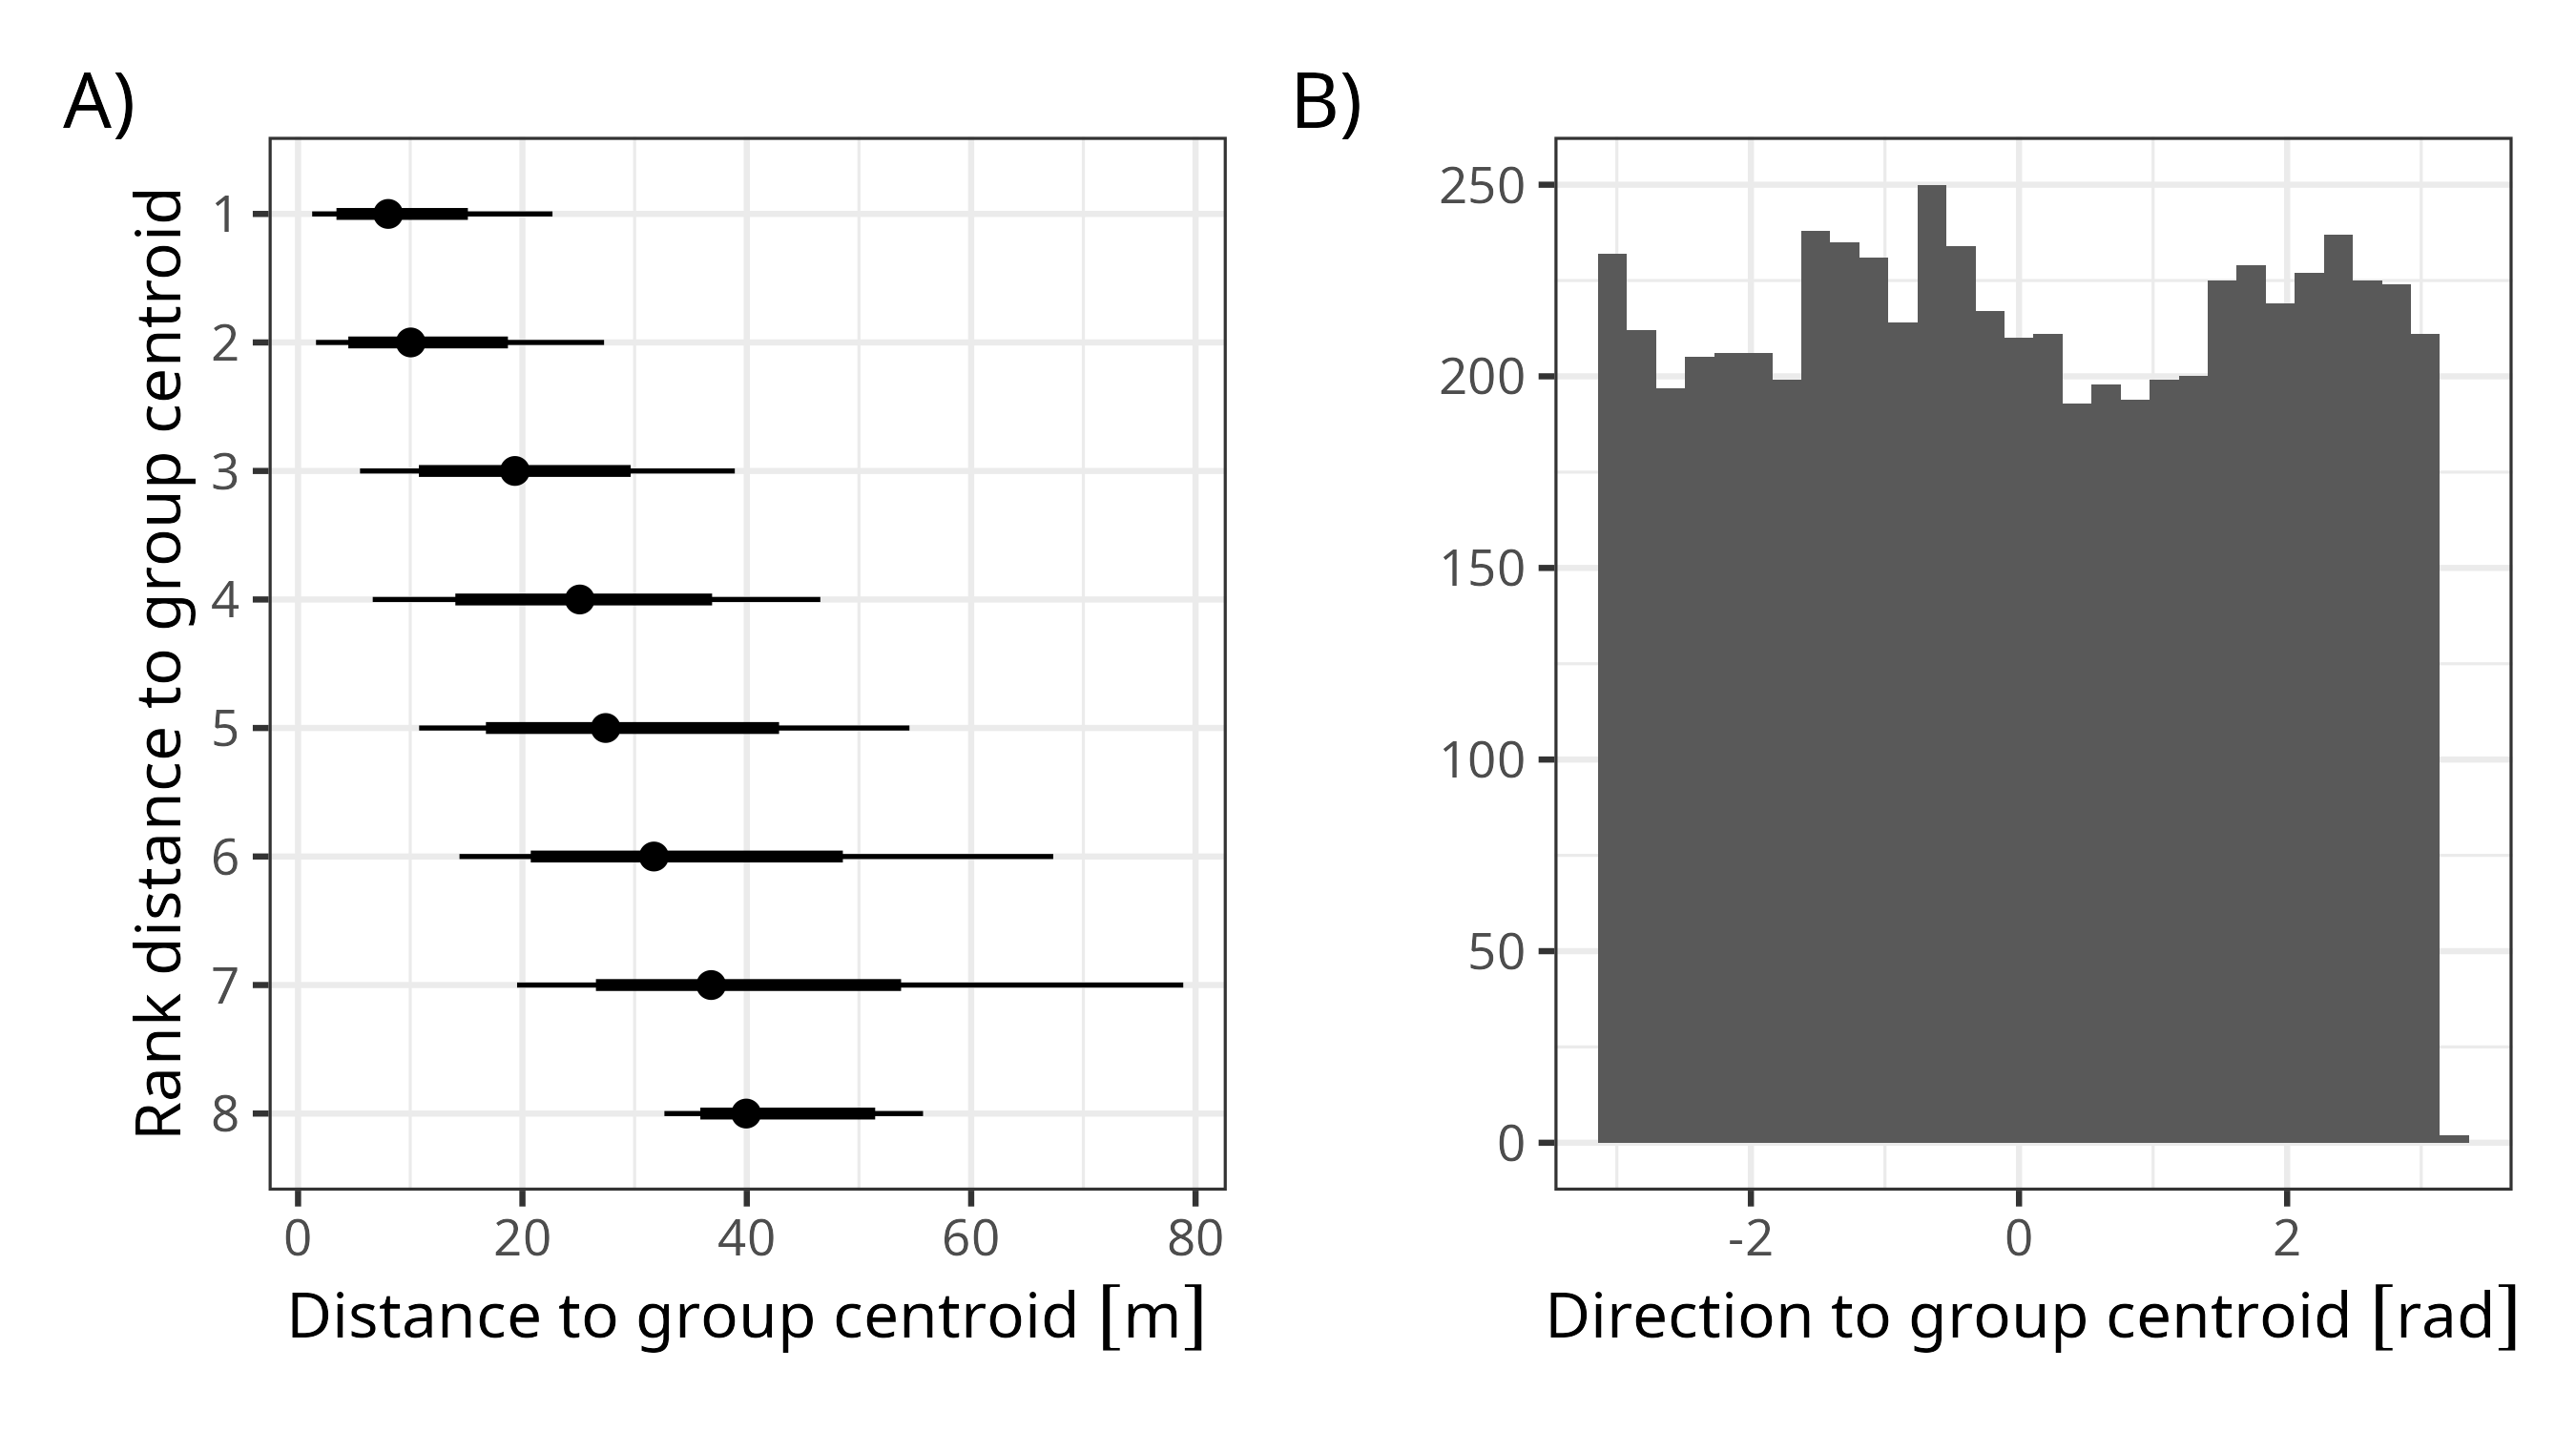

In [ ]:
# Measure movement direction
direction_step(DT, id = id)

# Measure mean movement direction of each spatiotemporal group
direction_group(DT)

In [ ]:
tar_load(group_directions)
sel_groups <- group_directions[ID != 'A'][, .N, by = group][N == 3][, sample(
  group,
  2
)]
tinytable::tt(group_directions[ID != 'A' & group %in% sel_groups][order(
  timegroup
)][, .(ID, timegroup, group, direction, group_direction)])

ID,timegroup,group,direction,group_direction
C,723,3390,-3.115 [rad],-2.852 [rad]
H,723,3390,-2.723 [rad],-2.852 [rad]
J,723,3390,-2.721 [rad],-2.852 [rad]
B,1278,2625,-1.943 [rad],-2.374 [rad]
E,1278,2625,-3.040 [rad],-2.374 [rad]
J,1278,2625,-2.172 [rad],-2.374 [rad]


We can measure polarization, the uniformity of movement directions in a group of individuals, using `direction_polarization()` (\[Figure @fig-dir-pol\]). Polarization is represented on a scale of 0-1 where values near 0 indicate that individuals in a group are moving in completely different directions (or “non-aligned”) and values near 1 indicate that individuals are moving in similar directions or (“aligned”). Polarization in the movement direction of groups of animals has been used to study cognition \[@Wang_2022\], learning \[@Vega-Trejo_2020\], the influence of habitat \[@Strandburg-Peshkin_2017\] and individual differences \[@Jolles_2017\] in collective behaviour.

In [ ]:
# Measure direction polarization
direction_polarization(DT)

![Direction polarization measured using direction_polarization(). Using the ‘direction’ column returned by direction_step() and ‘group’ column returned by group_pts(), direction_polarization() returns a column named ‘polarization’ indicating the polarization in directions in each spatiotemporal group. Ranges of directions shown for a sample of groups in four equal interval categories of direction polarization. Values of polarization range from 0 (non-alignment) to 1 (alignment).](attachment:graphics/fig_dir_polarization.png){#fig-dir-pol }

The interindividual direction, or direction from a focal individual to a neighbour, can be measured using `edge_direction()` (\[Figure @fig-edge-align-dir\]). Like `edge_alignment()`, the interindividual directions are returned by in an edge-list format. Interindividual direction has been used to study risk exposure in schooling fish \[@Lemasson_2014\], coordinated movement \[@Herbert-Read_2016\] and mass migration \[@Torney_2018\].
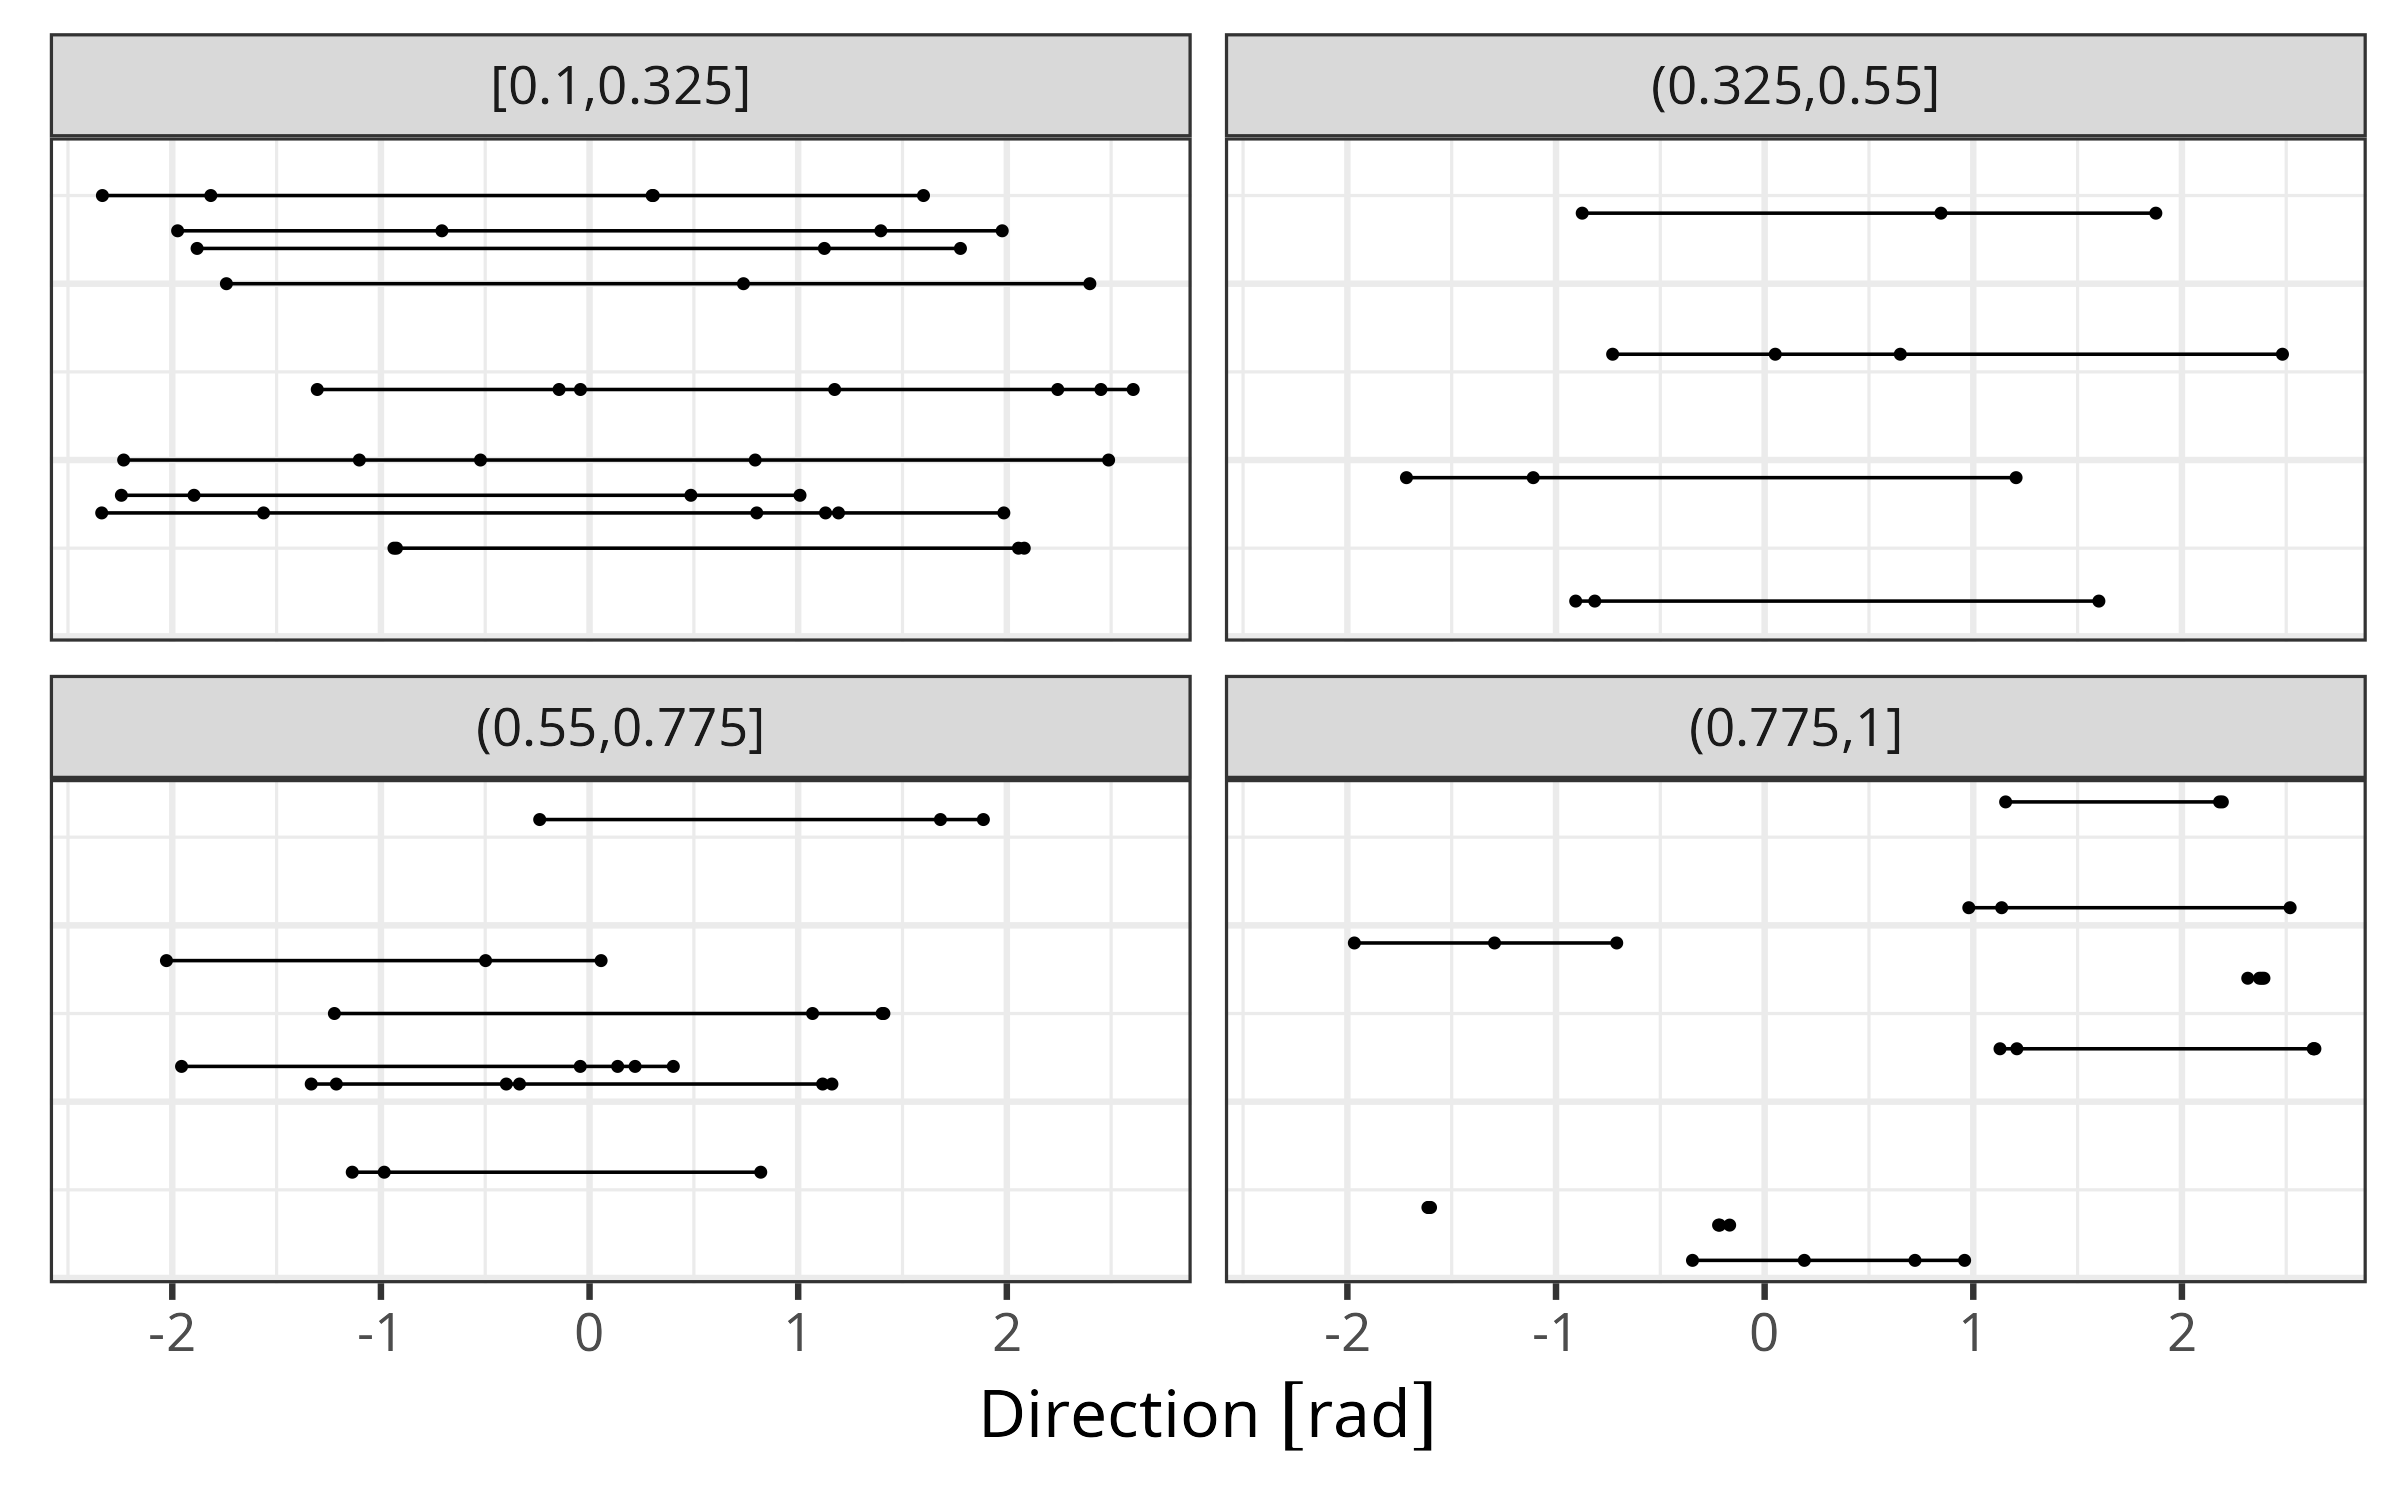

In [ ]:
# Measure interindividual direction
dyad_directions <- edge_direction(
  edges = interindividual_dist,
  DT = DT,
  id = id
)

The directional alignment, or relative difference between two individuals’ directions, can be measured using `edge_alignment()` (\[Figure @fig-edge-align-dir\]). The differences in movement directions are returned in an edge-list format similar to `edge_dist()` and other edge-list generating functions. Directional alignment has been used to study leadership \[@Sarova_2010\], decision making \[@Strandburg-Peshkin_2015\], and information transfer \[@Sumpter_2018\].

In [ ]:
# Measure directional alignment
directional_align <- edge_alignment(
  DT = DT,
  id = id,
  signed = FALSE
)

![A) Example locations for individuals ‘E’ (purple) and ‘F’ (blue) showing concurrent movement paths in timegroups 1, 2 and 3. B) Interindividual direction and directional_alignment() using edge_direction() and edge_alignment(). Using distance based edge-lists returned by edge_dist() or edge_nn() and the ‘timegroup’ column returned by group_times(), edge_direction() returns a column named ‘direction_dyad’ representing the direction between the focal individual (‘ID1’) and the neighbouring individual (‘ID2’). Using the ‘direction’ column returned by direction_step(), the edge_alignment() function returns a column named ‘direction_diff’ representing the absolute different in movement directions between two individuals (‘ID1’ and ‘ID2’). Optionally, the signed difference can be returned by edge_alignment() if the argument ‘signed’ is true.](attachment:graphics/fig_edge_dir_and_align.png){#fig-edge-align-dir }

## Behavioural zones

The behavioural zones \[@Couzin_2002\], or non-overlapping behavioural regions around a focal individual, can measured using `edge_zones()` (\[Figure @fig-edge-zones\]). The distance from the focal individual to each neighbour is used to assign the neighbours to behavioural zones. In addition, the direction from the focal individual to each neighbour can be used to determine if the neighbour is within a “blind volume” outside of the individual’s visual perception. @Couzin_2002 defined three non-overlapping zones. The “zone of repulsion” is at a minimum distance around the focal individual within which neighbours are expected to move away to avoid collisions. The “zone of orientation” is around the focal individual beyond the “zone of repulsion” within which neighbours are expected to orient themselves to the movement of their neighbours. The “zone of attraction” is beyond the “zone of orientation” where neighbours are expected to be attracted to the position of the focal individual. The `edge_zones()` function is designed to allow for flexible definitions of zones including distance thresholds, zone labels and blind volume thresholds. The behavioural zones metric has been used to study the impact of individual movement speed and predator evasion \[@Klamser_2021\] and identifying rules of interaction in large animal groups \[@Lukeman_2010\].
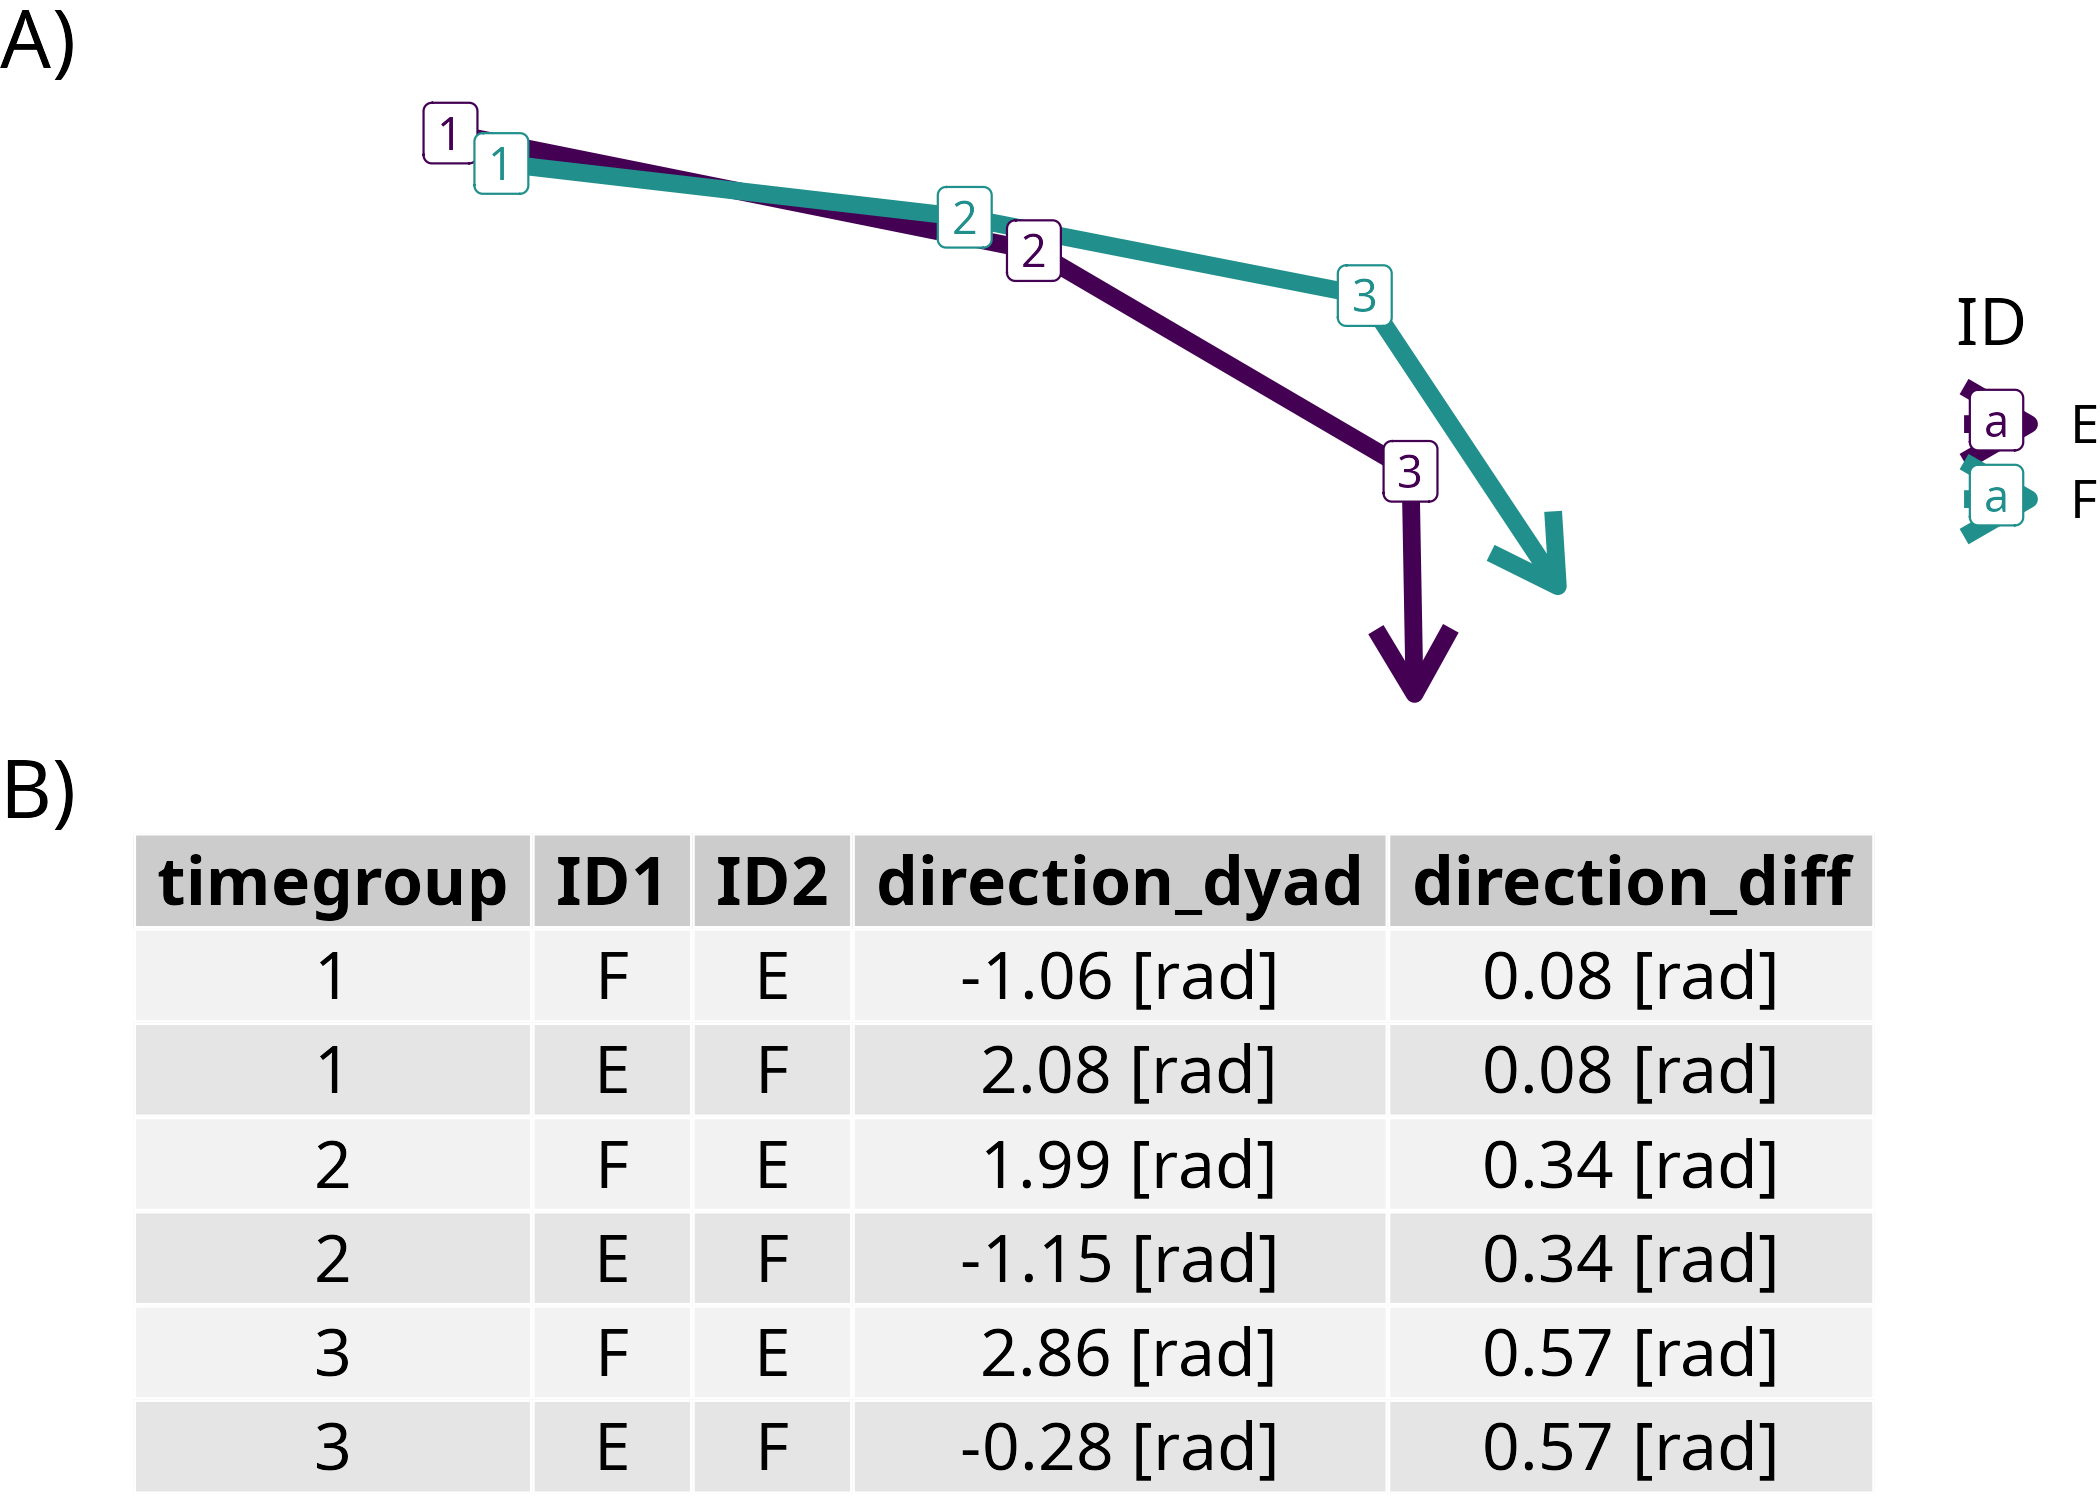

In [ ]:
# Define zone thresholds, labels and blind volume
zone_thresholds <- c(10, 25, 50)
zone_labels <- c('repulsion', 'orientation', 'attraction')
blind_volume <- 3

# Measure behavioural zones
zones <- edge_zones(
  dyad_directions,
  zone_thresholds = zone_thresholds,
  zone_labels = zone_labels,
  blind_volume = blind_volume
)

![Behavioural zones measured using edge_zones(). Using the ‘distance’ column returned by edge_dist(), the edge_zones() function returns the column ‘zone’ representing the behavioural zone of the neighbour (ID2) with respect to the focal individual (ID1). Optionally, the ‘direction_dyad’ column returned by edge_direction() can be used to define the blind volume, or the range of interindividual directions that are beyond the visual perception of the focal individual. Example shows positions of neighbour ‘E’ in behavioural zones with respect to focal individual ‘G’ across the sample period.](attachment:graphics/fig_edge_zones.png){#fig-edge-zones }

## Position relative to leader

After considering how individuals are positioned relative to the group centroid, we can also measure how individuals are positioned relative to the mean group direction. To do so, we first calculate each individual’s movement direction with `direction_step()` and the group’s mean direction with `direction_group()`. Then `leader_direction_group()` rotates the coordinate system around the group centroid by the group’s mean direction. The distance along this new axis is the measure of front-back position of an individual within the group \[@Quera_2023; @Harel_2021; @Andrienko_2013\] (\[Figure @fig-leader-dir-group\]). The rank of individual positions within spatiotemporal groups \[@Burns_2012\] can be optionally returned when the argument ‘return_rank’ is true.
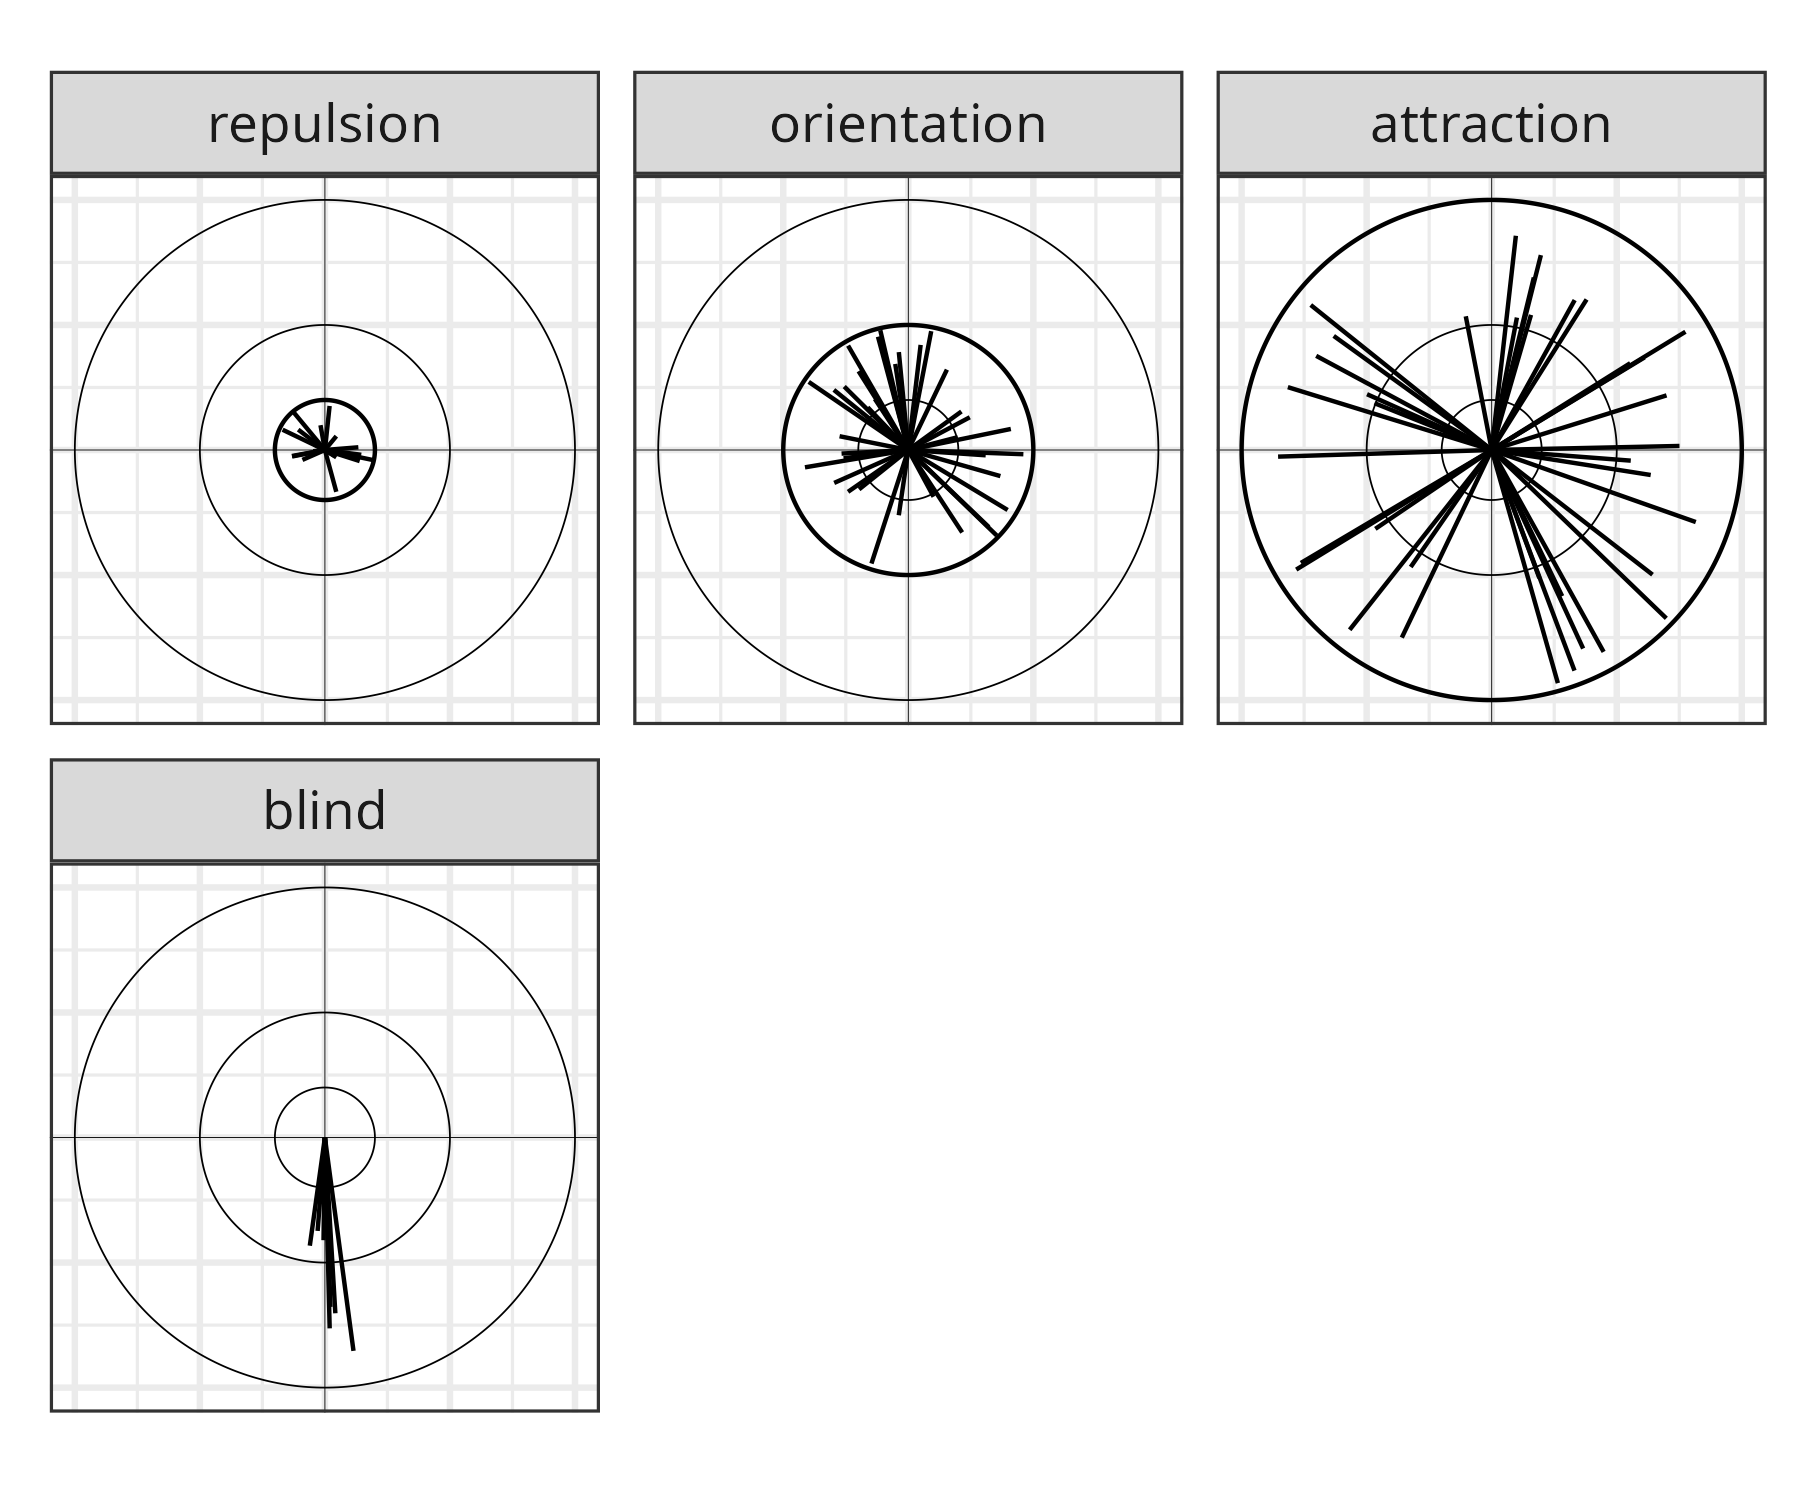

In [ ]:
# Measure movement direction
direction_step(DT, id = id)

# Measure mean movement direction of each spatiotemporal group
direction_group(DT)

# Measure position relative to leader
leader_direction_group(DT, return_rank = TRUE)

![A) Example spatiotemporal group showing relative positions and movement directions of individuals (small points and grey arrows) with respect to the group centroid and mean group direction (large point and black arrow). B) Position along the group direction measured using leader_direction_group(). Using the ‘direction’ column returned by direction_step(), ‘group_direction’ column returned by direction_group() and ‘centroid’ column returned by centroid_group(), leader_direction_group() returns a column named ‘position_group_direction’ representing the front-back position along the mean group direction. Optionally, the rank position along the mean group direction if ‘return_rank’ is true.](attachment:graphics/fig_pos_group_dir.png){#fig-leader-dir-group }

Taking this simple, dynamic definition of leadership, we can identify the distance and direction of individuals to the leader of each spatiotemporal group using `distance_to_leader()` and `direction_to_leader()` (\[Figure @fig-dist-dir-lead\]). The distance to leader is the geographic distance from the focal individual to the group’s leader and the direction to leader is the direction from the focal individual to the group’s leader. The front-back position within the group, and distance and direction to the group leader has been used to study interaction rules \[@Weesner_2023\], leadership \[@Quera_2023; @Sarova_2010\], risk avoidance \[@Josephs_2016\], and how reproduction influences social structure \[@Perez-Barberia_2018\]. In addition, a user can calculate an individual’s time spent leading by calculating the rate each individual was in the first ranked position out of the total observations.
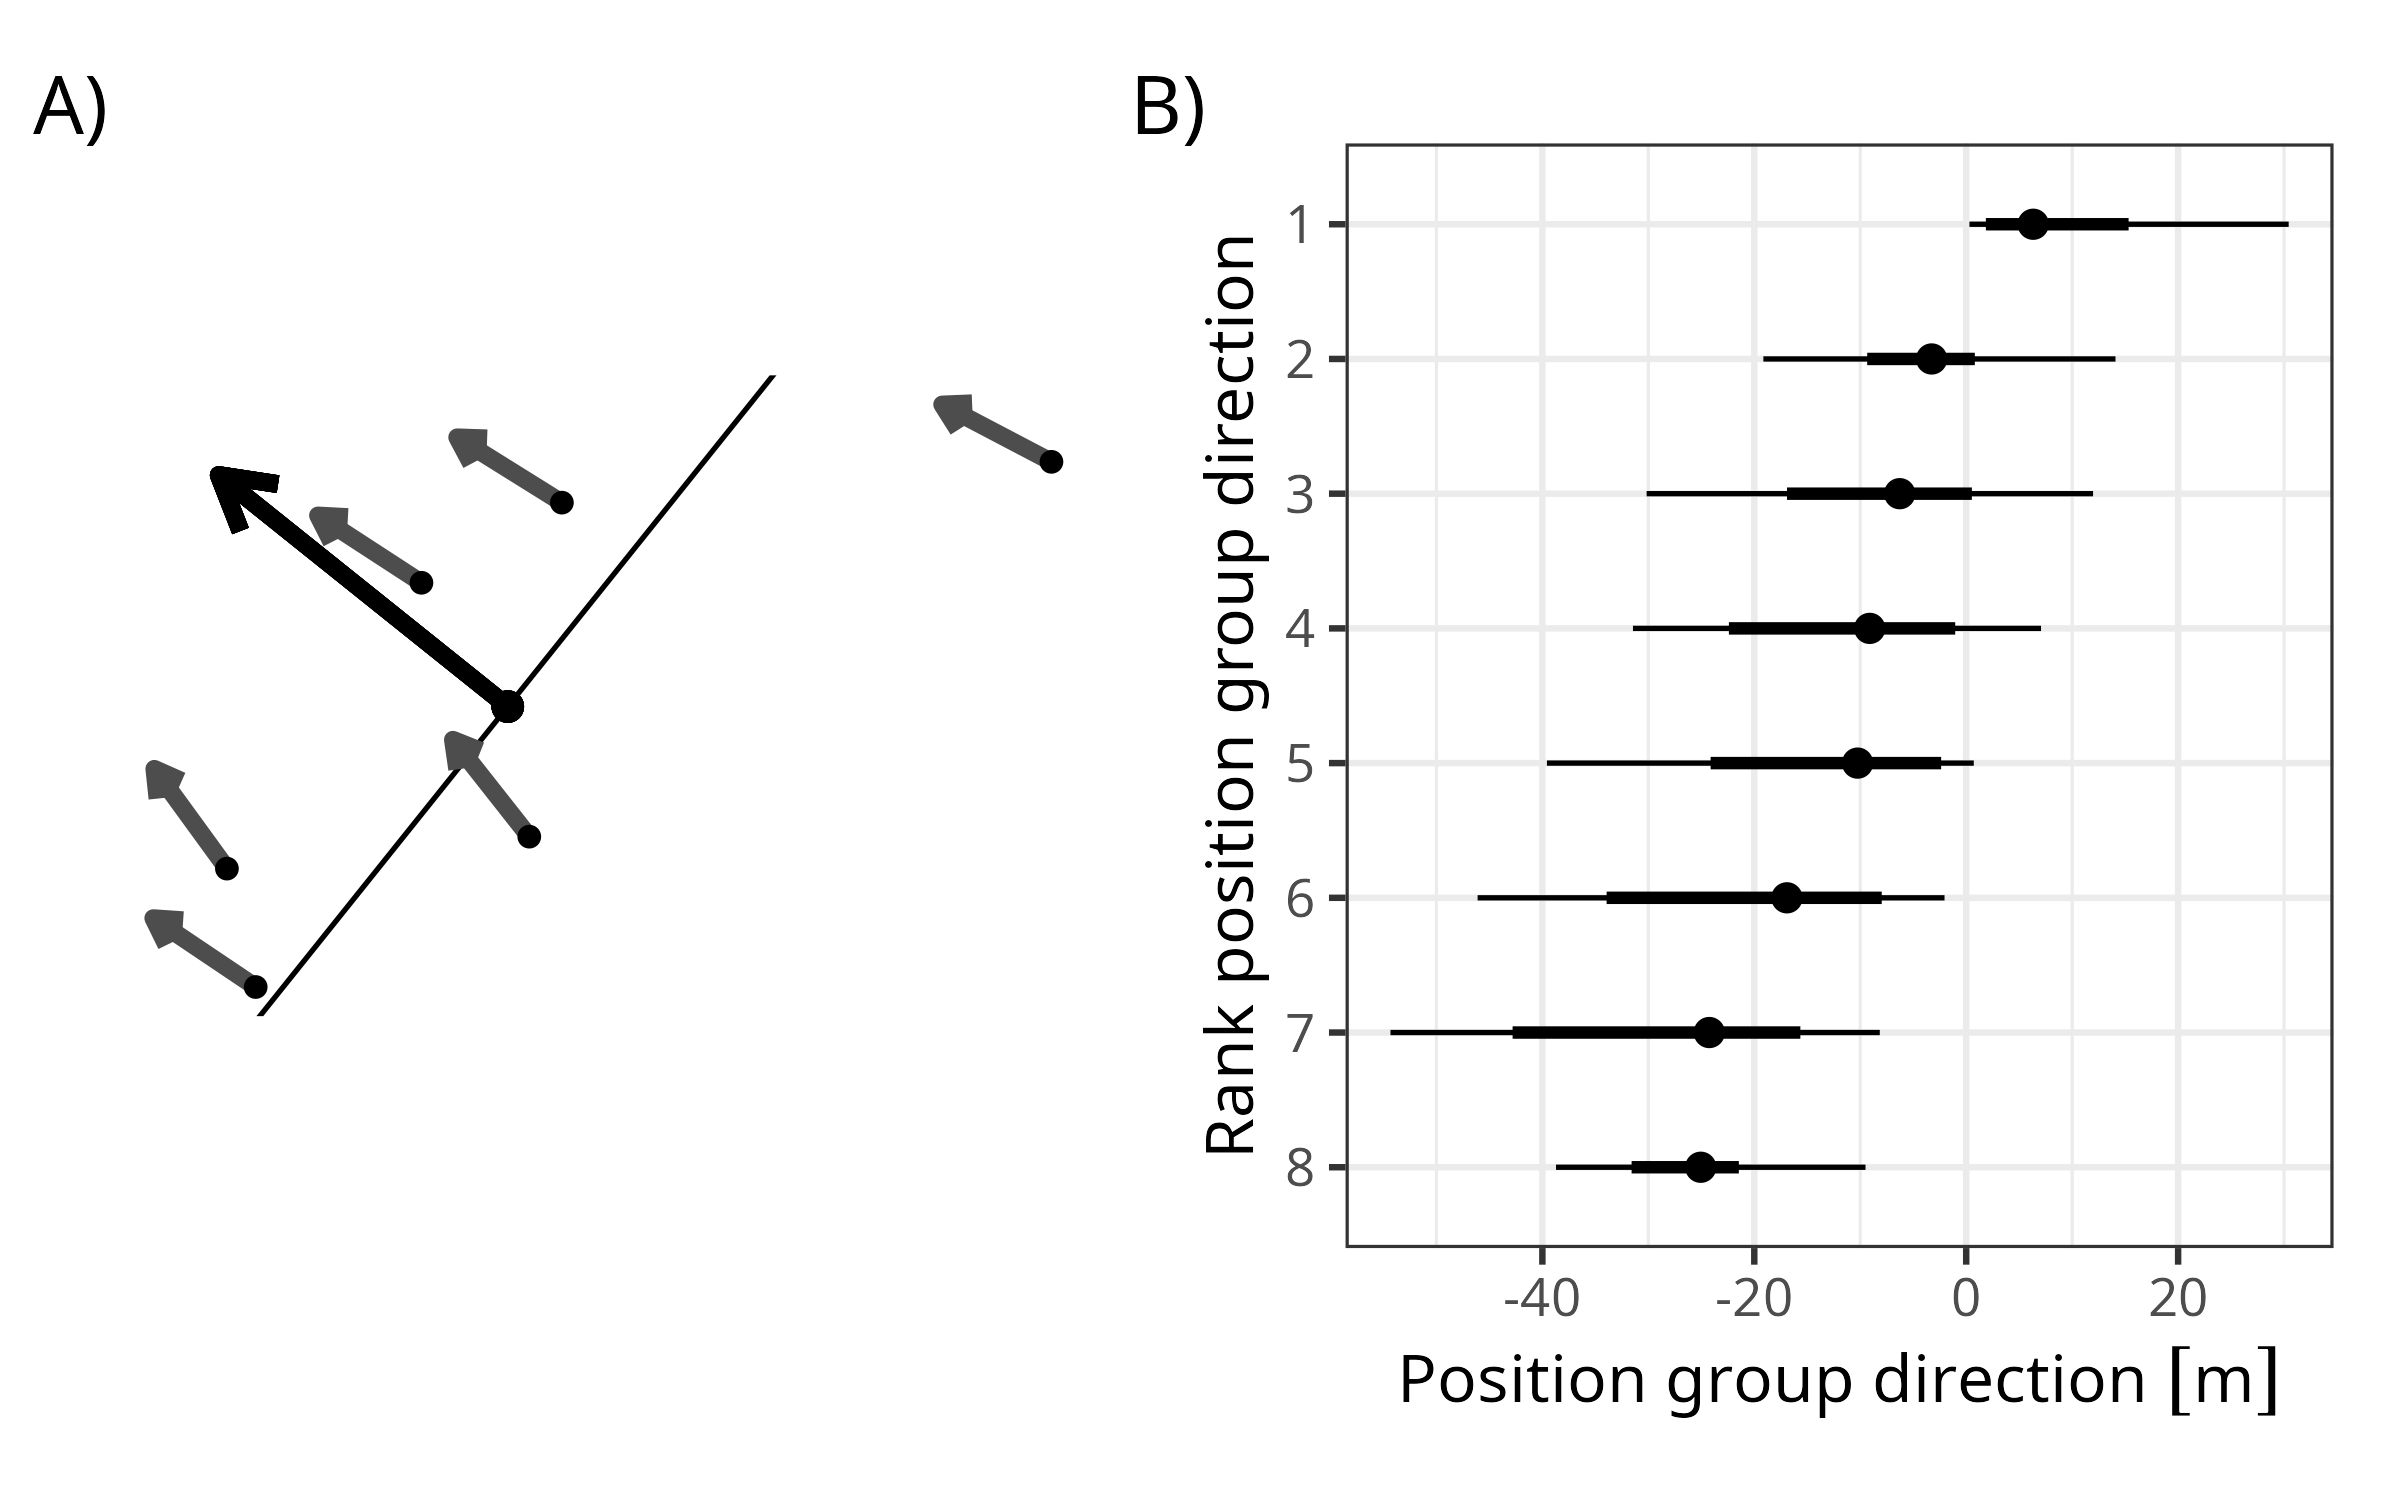

In [ ]:
# Measure distance to leader
distance_to_leader(DT)

# Measure direction to leader
direction_to_leader(DT)

![A) Distance and B) direction to group leaders measured using distance_to_leader and direction_to_leader. Using the ‘rank_position_group_direction’ column returned by leader_direction_group(), distance_to_leader() and direction_to_leader() return columns named ‘distance_leader’ and ‘direction_leader’ indicating the distance and direction of the focal individual to the leader of the spatiotemporal group. Note: for individuals identified as leader using ‘position_group_direction’, the distance is 0 and the direction is NA.](attachment:graphics/fig_dist_dir_leader.png){#fig-dist-dir-lead }

## Fusion events

Fusion events, or temporal periods where two individiuals are within a given threshold distance from each other, can be identified using `fusion_id()` (\[Figure @fig-fusion\]). Given the variability in defining fission fusion dynamics in the literature (\[@tbl-defn-fission\]), the `fusion_id()` function flexibly allows users to use specific thresholds and definitions that match their study species and research questions. This will also allow users to easily compare their results to previously published work by using the same thresholds and definitions. The `threshold` argument defines the spatial distance threshold to establish a fusion event. The `n_min_length` argument defines the minimum number of successive fixes that are required to establish a fusion event. The `n_max_missing` defines the maximum number of allowable missed observations for either individual in a dyad within a fusion event. The `allow_split` argument defines if fusion events allow a temporary spatial splitting for one observation without resulting in a fission event. Identification of fusion events has been used to study resource seasonality \[@Baden_2016\], information transfer \[@Barocas_2016\], decision making \[@Merkle_2015\], and habitat selection \[@Fortin_2009\].
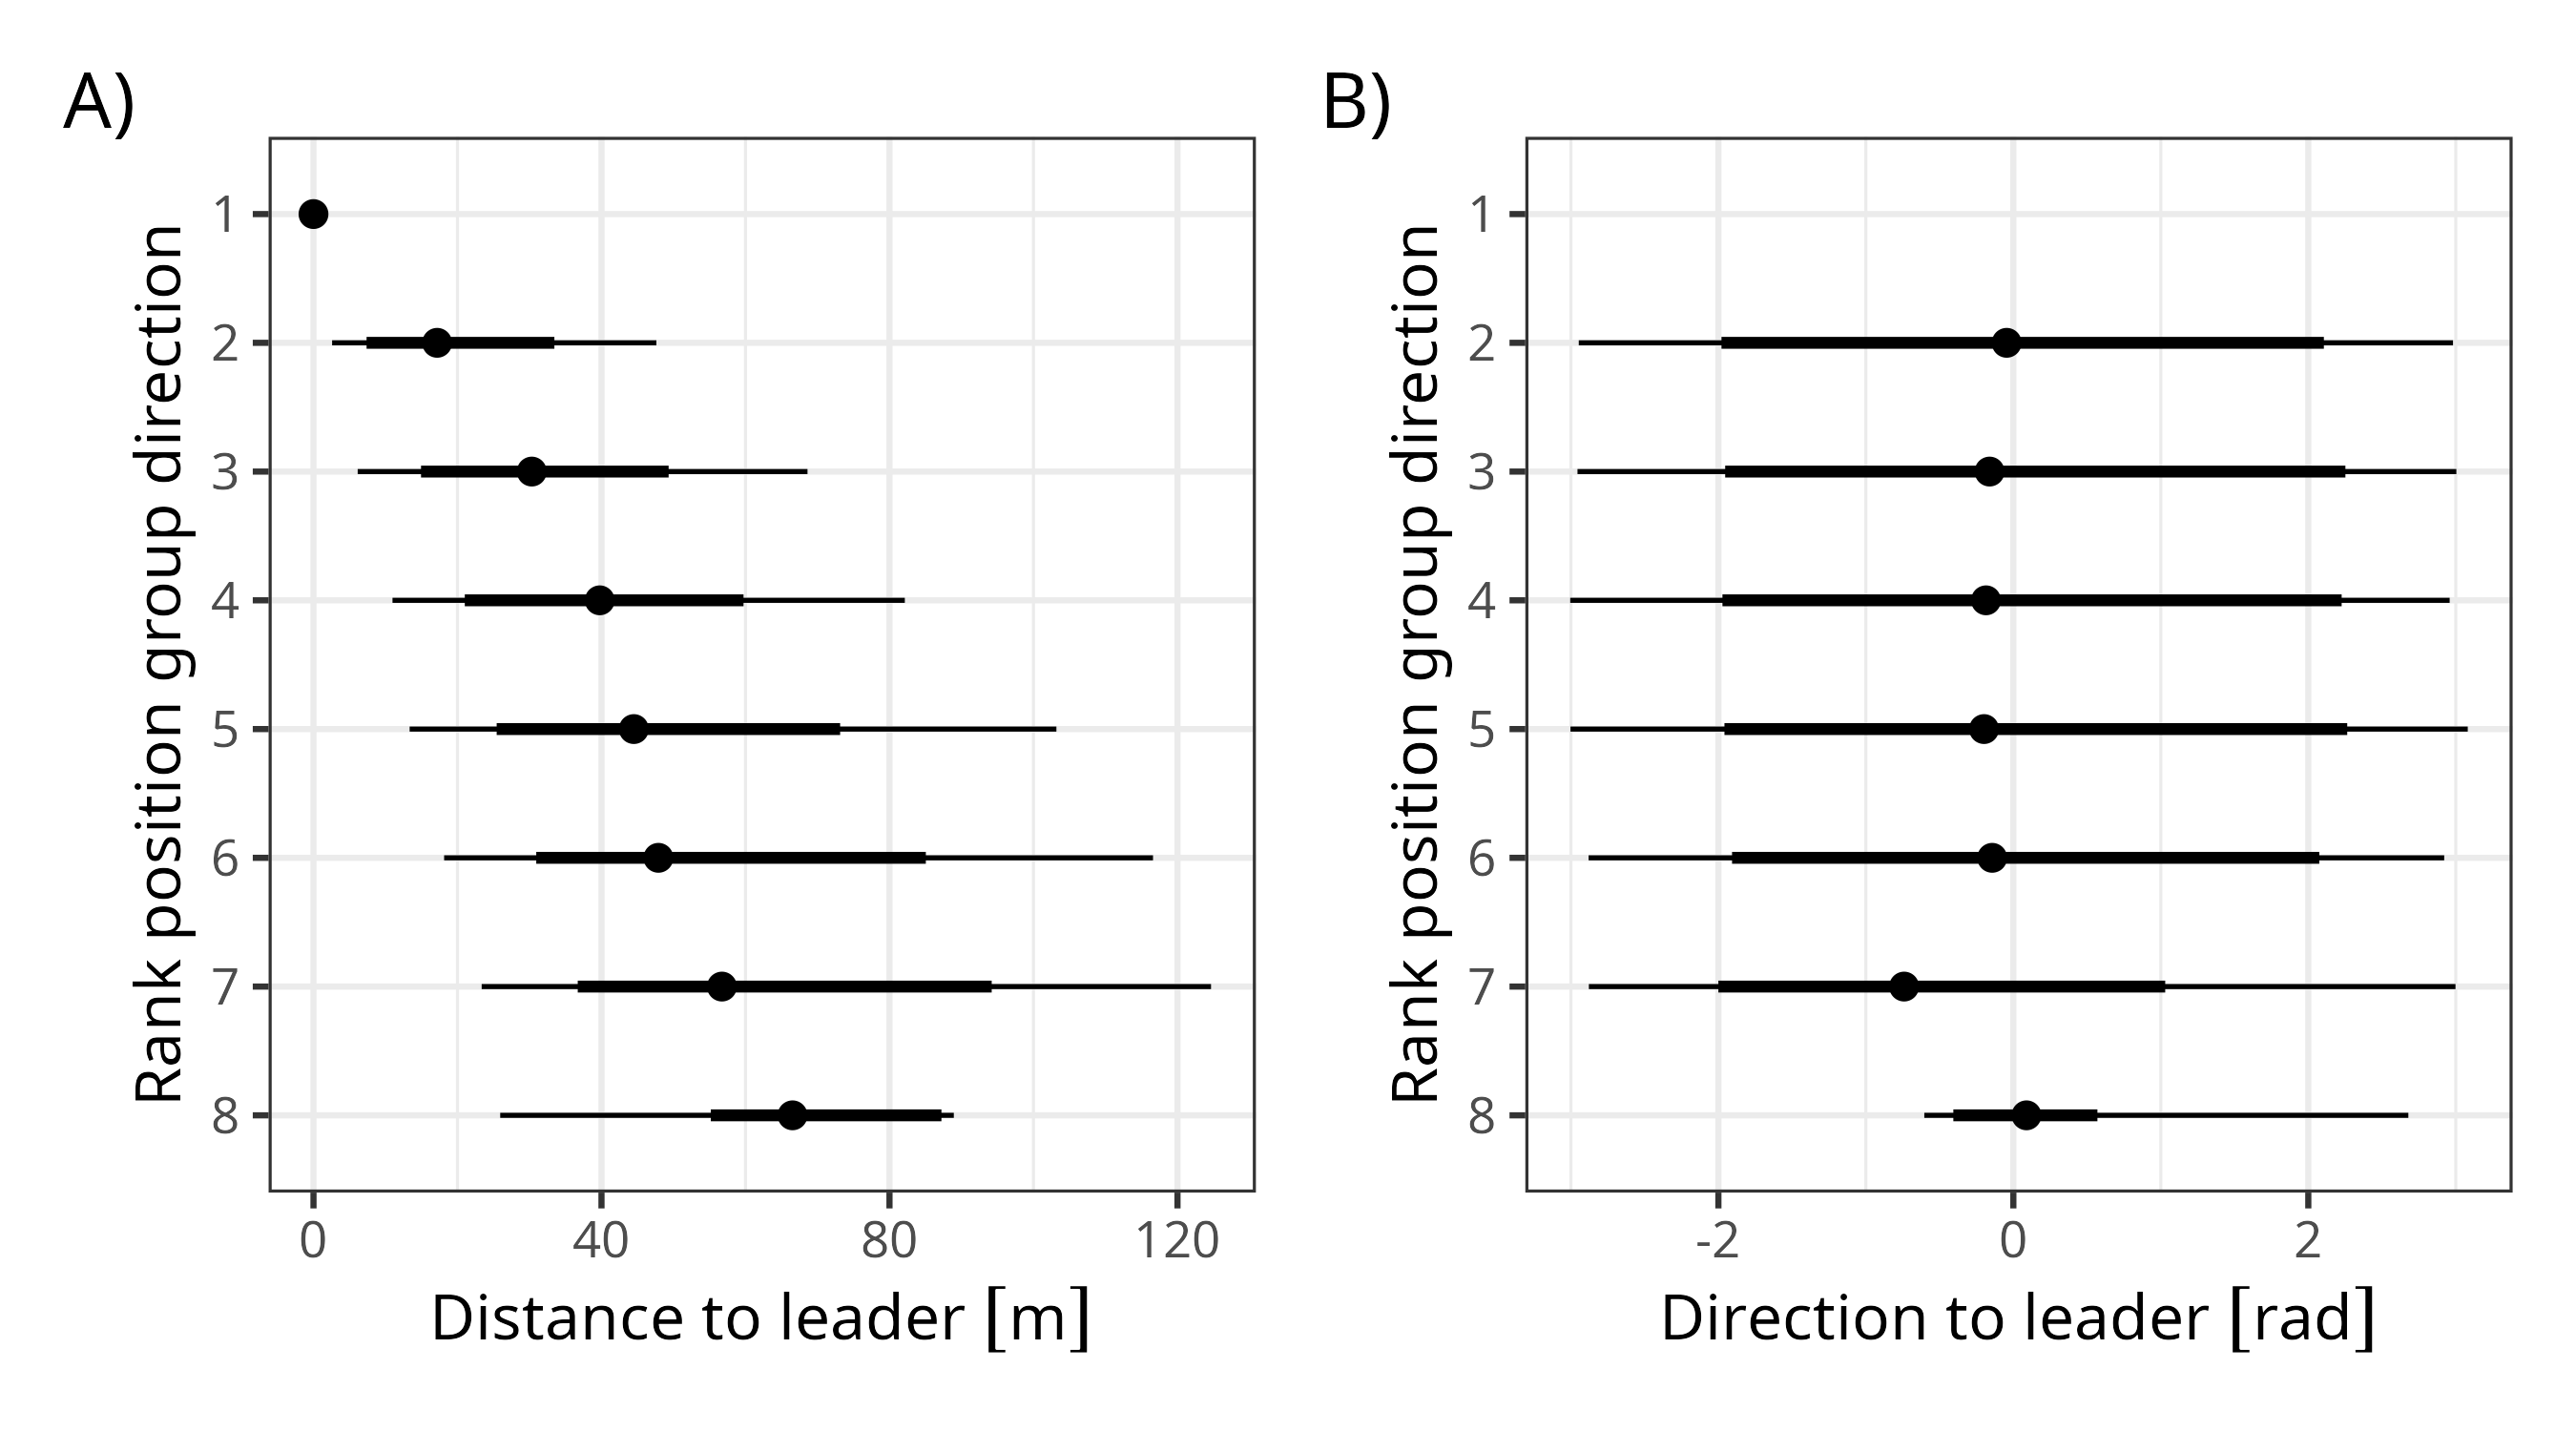

In [ ]:
# Identify dyads
dyad_id(interindividual_dist, id1 = 'ID1', id2 = 'ID2')

# Identify fusion events
fusion_events <- fusion_id(
  interindividual_dist,
  threshold = spatial_threshold,
  n_min_length = 3,
  n_max_missing = 1,
  allow_split = TRUE
)

# Measure centroids of fusion events
centroid_fusion(
  interindividual_dist,
  DT,
  id = id
)

![A) Example fusion event for individuals ‘J’ and ‘C’ with black points representing the centroid of fusion observations returned by centroid_fusion(). B) A fusion event identified using fusion_id. Using the distance based edge-lists measured using edge_dist() and the dyad id returned by dyad_id(), fusion_id() a returns a column named ‘fusionID’ representing the fusion events defined with user specified constraints: the distance threshold (‘threshold’), the minimum number of observations defining a fusion event (‘n_min_length’), the maximum number of missing observations from either individual in a fusion event (‘n_max_missing’) and if a single observation where individuals are beyond the distance threshold should result in a fission event (‘allow_split’). In B), a fusion event is identified for individuals J and C given they are within the distance threshold at timegroups 2, 3, and 4. Individual J is shown at timegroups 1 and 5 with no neighbours within the threshold spatial distance (ID2 is NA).](attachment:graphics/fig_fusion_events.png){#fig-fusion }

## Directional correlation delay

The directional correlation delay \[@Nagy_2010\], or the temporal delay at which two individual’s movement directions are most similar, can be measured using `edge_delay()` (\[Figure @fig-edge-delay\]). The function measures the similarity of movement directions of the focal individual at time $t_{0}$ and the movement direction’s of a neighbour within a specified temporal window (eg. $t_{-2}, t_{-1}, t_{0}, t_{1}, t_{2}$). The temporal delay is the difference in time where the neighbour’s movement directions are most similar to the focal individual’s. The directional correlation delay ranges from negative values indicating the focal individual’s direction is most similar to the neighbour’s previous movement direction to positive values indicating the focal individual’s direction is most similar to the neighbour’s future movement direction. The directional correlation delay can be aggregated to determine mean directional correlation delay using `leader_edge_delay()`. The mean directional correlation delay can be used to measure leadership patterns and generate hierarchical leadership networks depending on the study system \[@Nagy_2010; @Flack_2013; @Nagy_2013; @Quera_2023; @Akos_2014\].
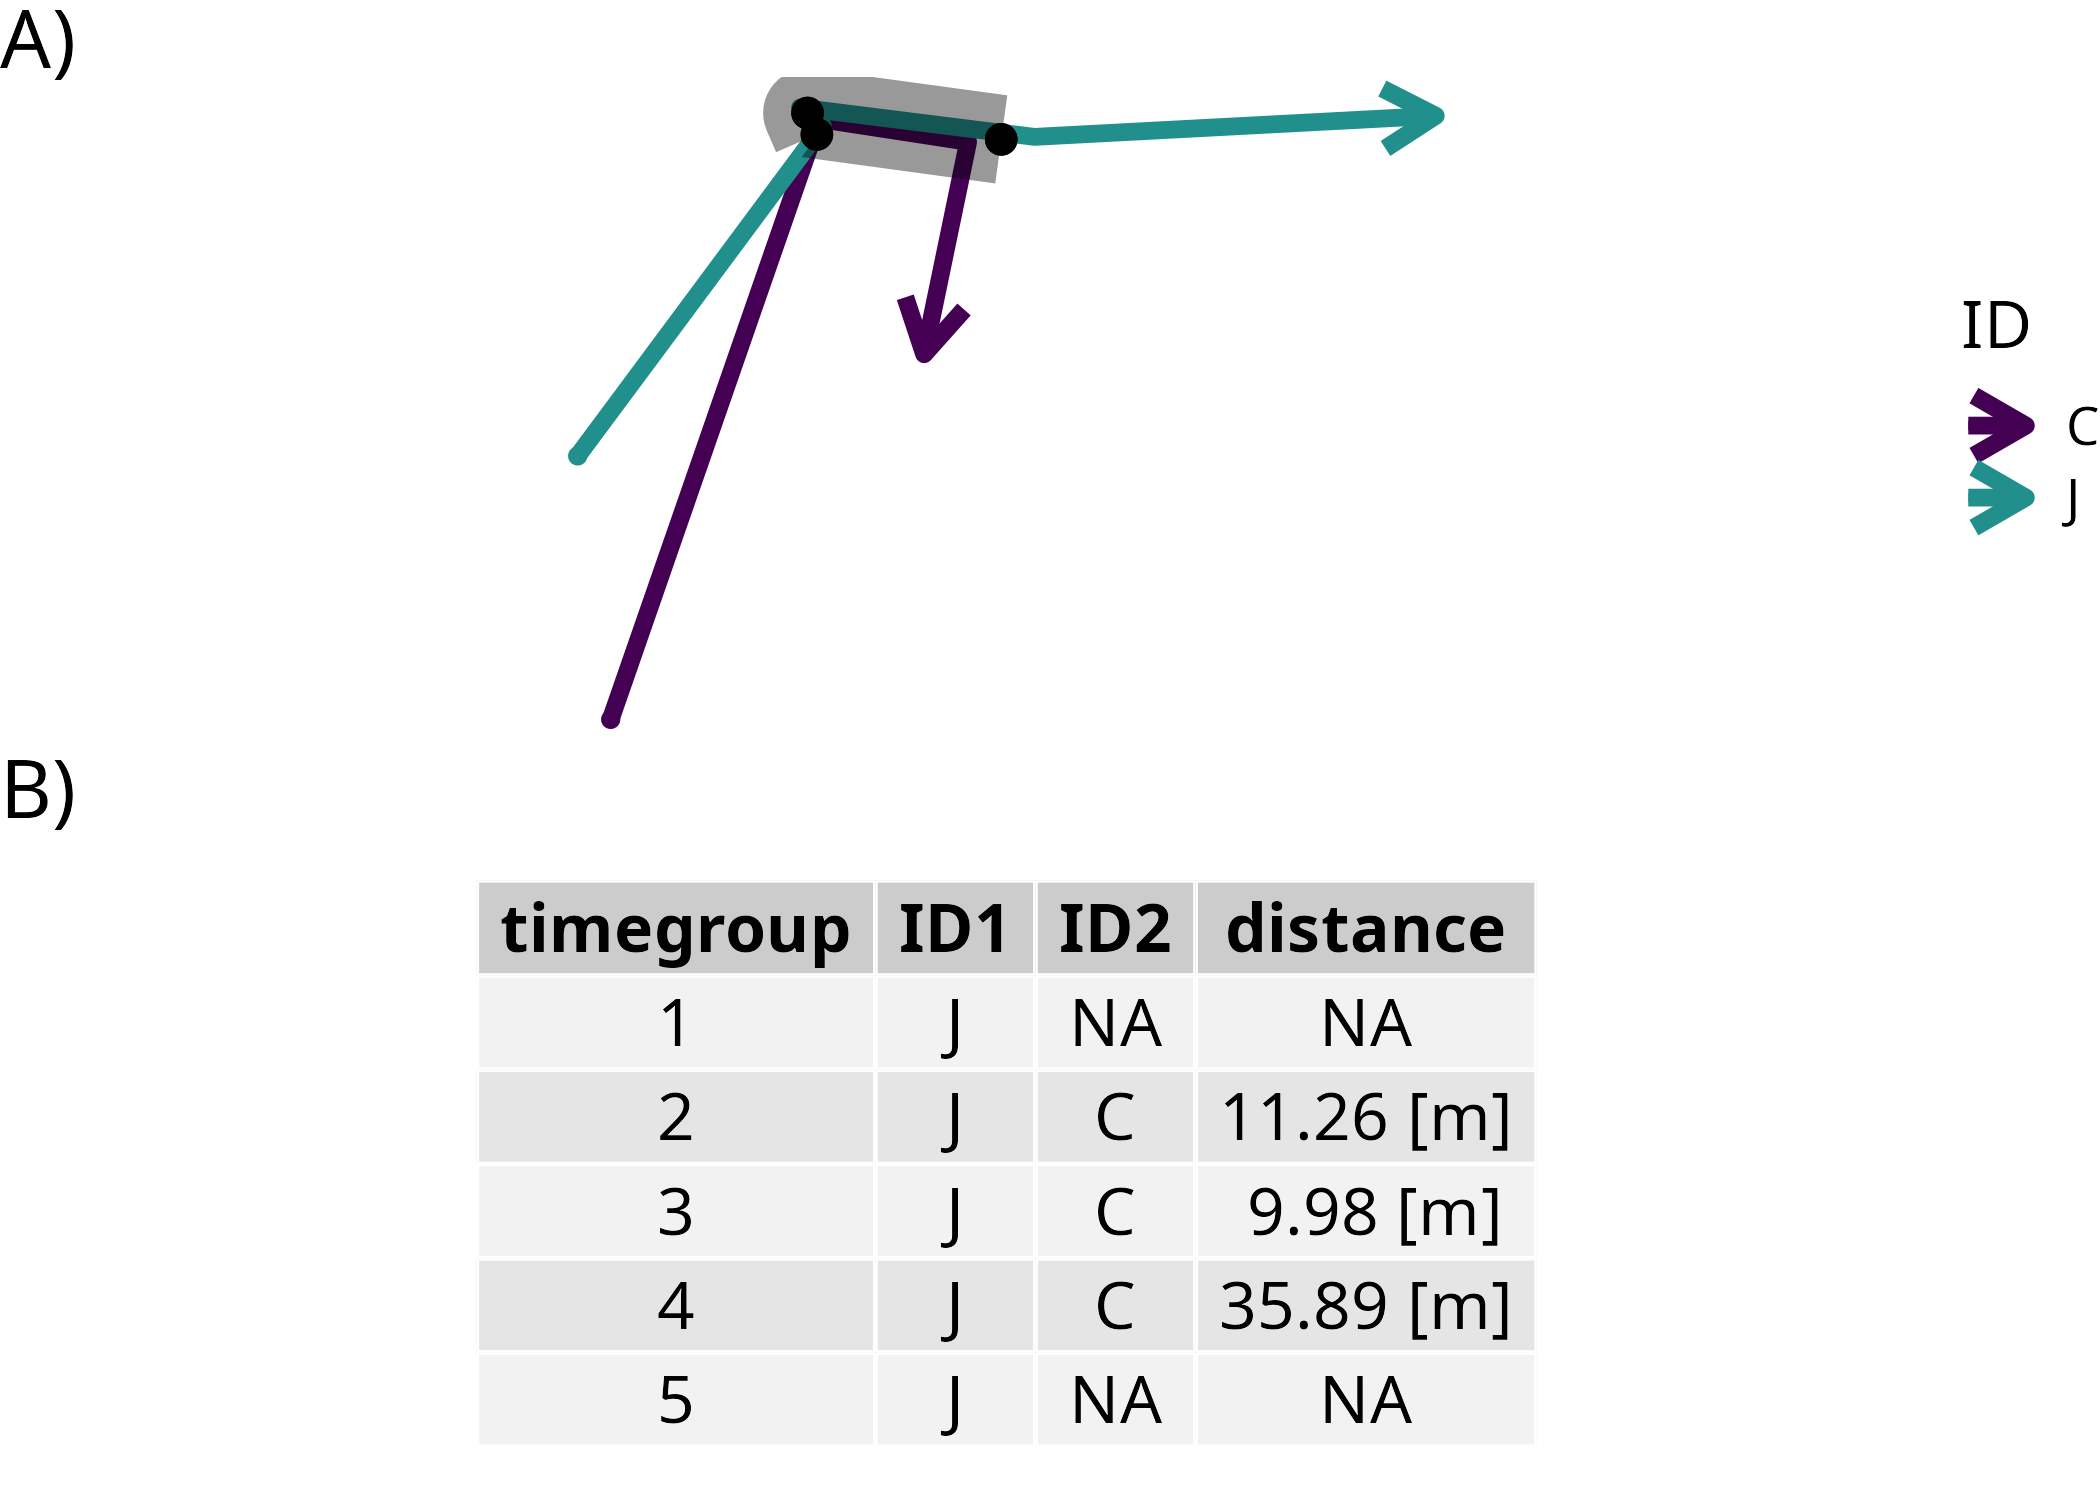

In [ ]:
# Measure directional correlation delay
delay <- edge_delay(
  edges = fusion_events,
  DT = DT,
  window = 3,
  id = id
)

In [ ]:
# Measure mean directional correlation delay
leader_delay <- leader_edge_delay(
  delay,
  threshold = 0.5
)

![A) Example directional correlation delay for focal individual ‘C’ (ID1) and neighbour ‘G’ (ID2) indicating individual ‘C’ had a movement direction most similar to individual ‘G’ at the temporal delay of 0. Using the fusion events identified by fusion_id() and the ‘direction’ column returned by direction_step(), edge_delay() returns a column named ‘direction_delay’ representing the temporal delay at which the focal individual’s movement direction is most similar to their neighbour’s within a temporal window. B) Example movement directions for neighbour ‘G’ in the temporal window of timegroups 1-3 (set using argument ‘window’). C) Aggregated directional delay using leader_edge_delay(). Using the ‘direction_delay’ column returned by edge_delay(), the leader_edge_delay() function returns a column named ‘mean_direction_delay_delay’ representing the mean directional correlation delay between two individuals and a column named ‘mean_direction_delay’ that represents the the mean correlation delay for each focal individual and all observed neighbours. Optionally, a threshold difference in direction can be used to subset the temporal delays included in the calculation of mean directional delay with the argument ‘threshold’.](attachment:graphics/fig_edge_delay.png){#fig-edge-delay }

# Implications

The open source package {spatsoc} \[@Robitaille_2019\] for the R programming language \[@RCoreTeam_2025a\] has improved accessibility to methods for spatiotemporal grouping and social network analysis with animal telemetry data \[eg. @Albery_2025; @Bracken_2022; @Merkle_2024; @Heeres_2024\]. Despite this, proximity based associations are only one dimension and studying intragroup social dynamics will allow researchers to further measure animal social systems. The new functions in {spatsoc} and the accompanying case study presented here make openly available a series of metrics that while commonly used in the literature have been largely absent from R packages. Paired with the continued development of animal tracking technology \[@Nathan_2022; @Beardsworth_2022\] and novel data collection methods \[@Koger_2023; @Pedrazzi_2025\], the open availability of these metrics in R will broaden their application across research questions, including long-standing ecological concepts such as:

-   Social foraging theory and producer-scrounger dynamics where “producers” are those who discover patches and “scroungers” are those who join patches discovered by others \[@Barnard_1981; @Vickery_1991; @Giraldeau_2000\]. This concept can be applied to animal telemetry data by evaluating the position of individuals within groups, the individual’s arrival timing to forage patches and the characteristics of forage patches. Individuals balance predation risk and foraging success by adjusting their spatial position within groups \[@Teichroeb_2015; @Hirsch_2020\], and the foraging strategy selected by an individual can be influenced by the size of forage patches \[@Hansen_2016\].

-   Leader-follower patterns in groups of moving animals can be studied both to determine factors that causally influence leadership, and for the influence of leader-follower strategies on foraging success and downstream fitness. Applied to animal telemetry data, leadership can be defined simply by identifying the individual at the foremost position along the front-to-back axis of the group’s direction \[@Quera_2023; @Harel_2021\] or by calculating the directional correlation delay between individuals and building leadership hierarchies \[@Nagy_2010\]. Leadership in a group of moving animals can inform animal decision making, group coordination, and migratory patterns \[@Flack_2018; @Weesner_2023; @Quera_2023; @Kano_2021\].

-   Individual traits can influence behaviours related to intragroup dynamics. Dominance is related to foraging success \[@Caraco_1989; @Teichroeb_2015\] and choice of foraging strategy \[@King_2009; @Aplin_2017; @Lee_2016\]. Dominant, aggressive, grooming and other interindividual behaviours are typically measured using focal observations. However, some metrics have been developed for remotely estimating dominance behaviours. The directional correlation delay can be used to derive hierarchies of leadership which can be a proxy for dominance relationships in certain species \[@Flack_2013; @Akos_2014\]. Dominance relationships can also be inferred from animal telemetry data using movement initiations \[@Amornbunchornvej_2018\], approach-avoidance behaviours \[@Strandburg-Peshkin_2015\] and displacement events \[@Evans_2018\].

The lack of open source code and transparency of methods alongside research (\[@tbl-code-availability\], \[@tbl-prog\], \[@tbl-software\]) continues to slow the progress of science by limiting the broader application of new methods. We hope that the availability of these metrics in {spatsoc} will allow researchers to apply them to diverse study species, systems or research questions, including novel applications that could have management and conservation implications for vulnerable species \[@Ramos_2021\].

# Open science

All code used to produce this manuscript including figures and tables are available on GitHub at LINK <!-- TODO: github link --> and on Zeonodo at LINK <!-- TODO: github link -->. The data used in this case study are included with the package and can be imported with:
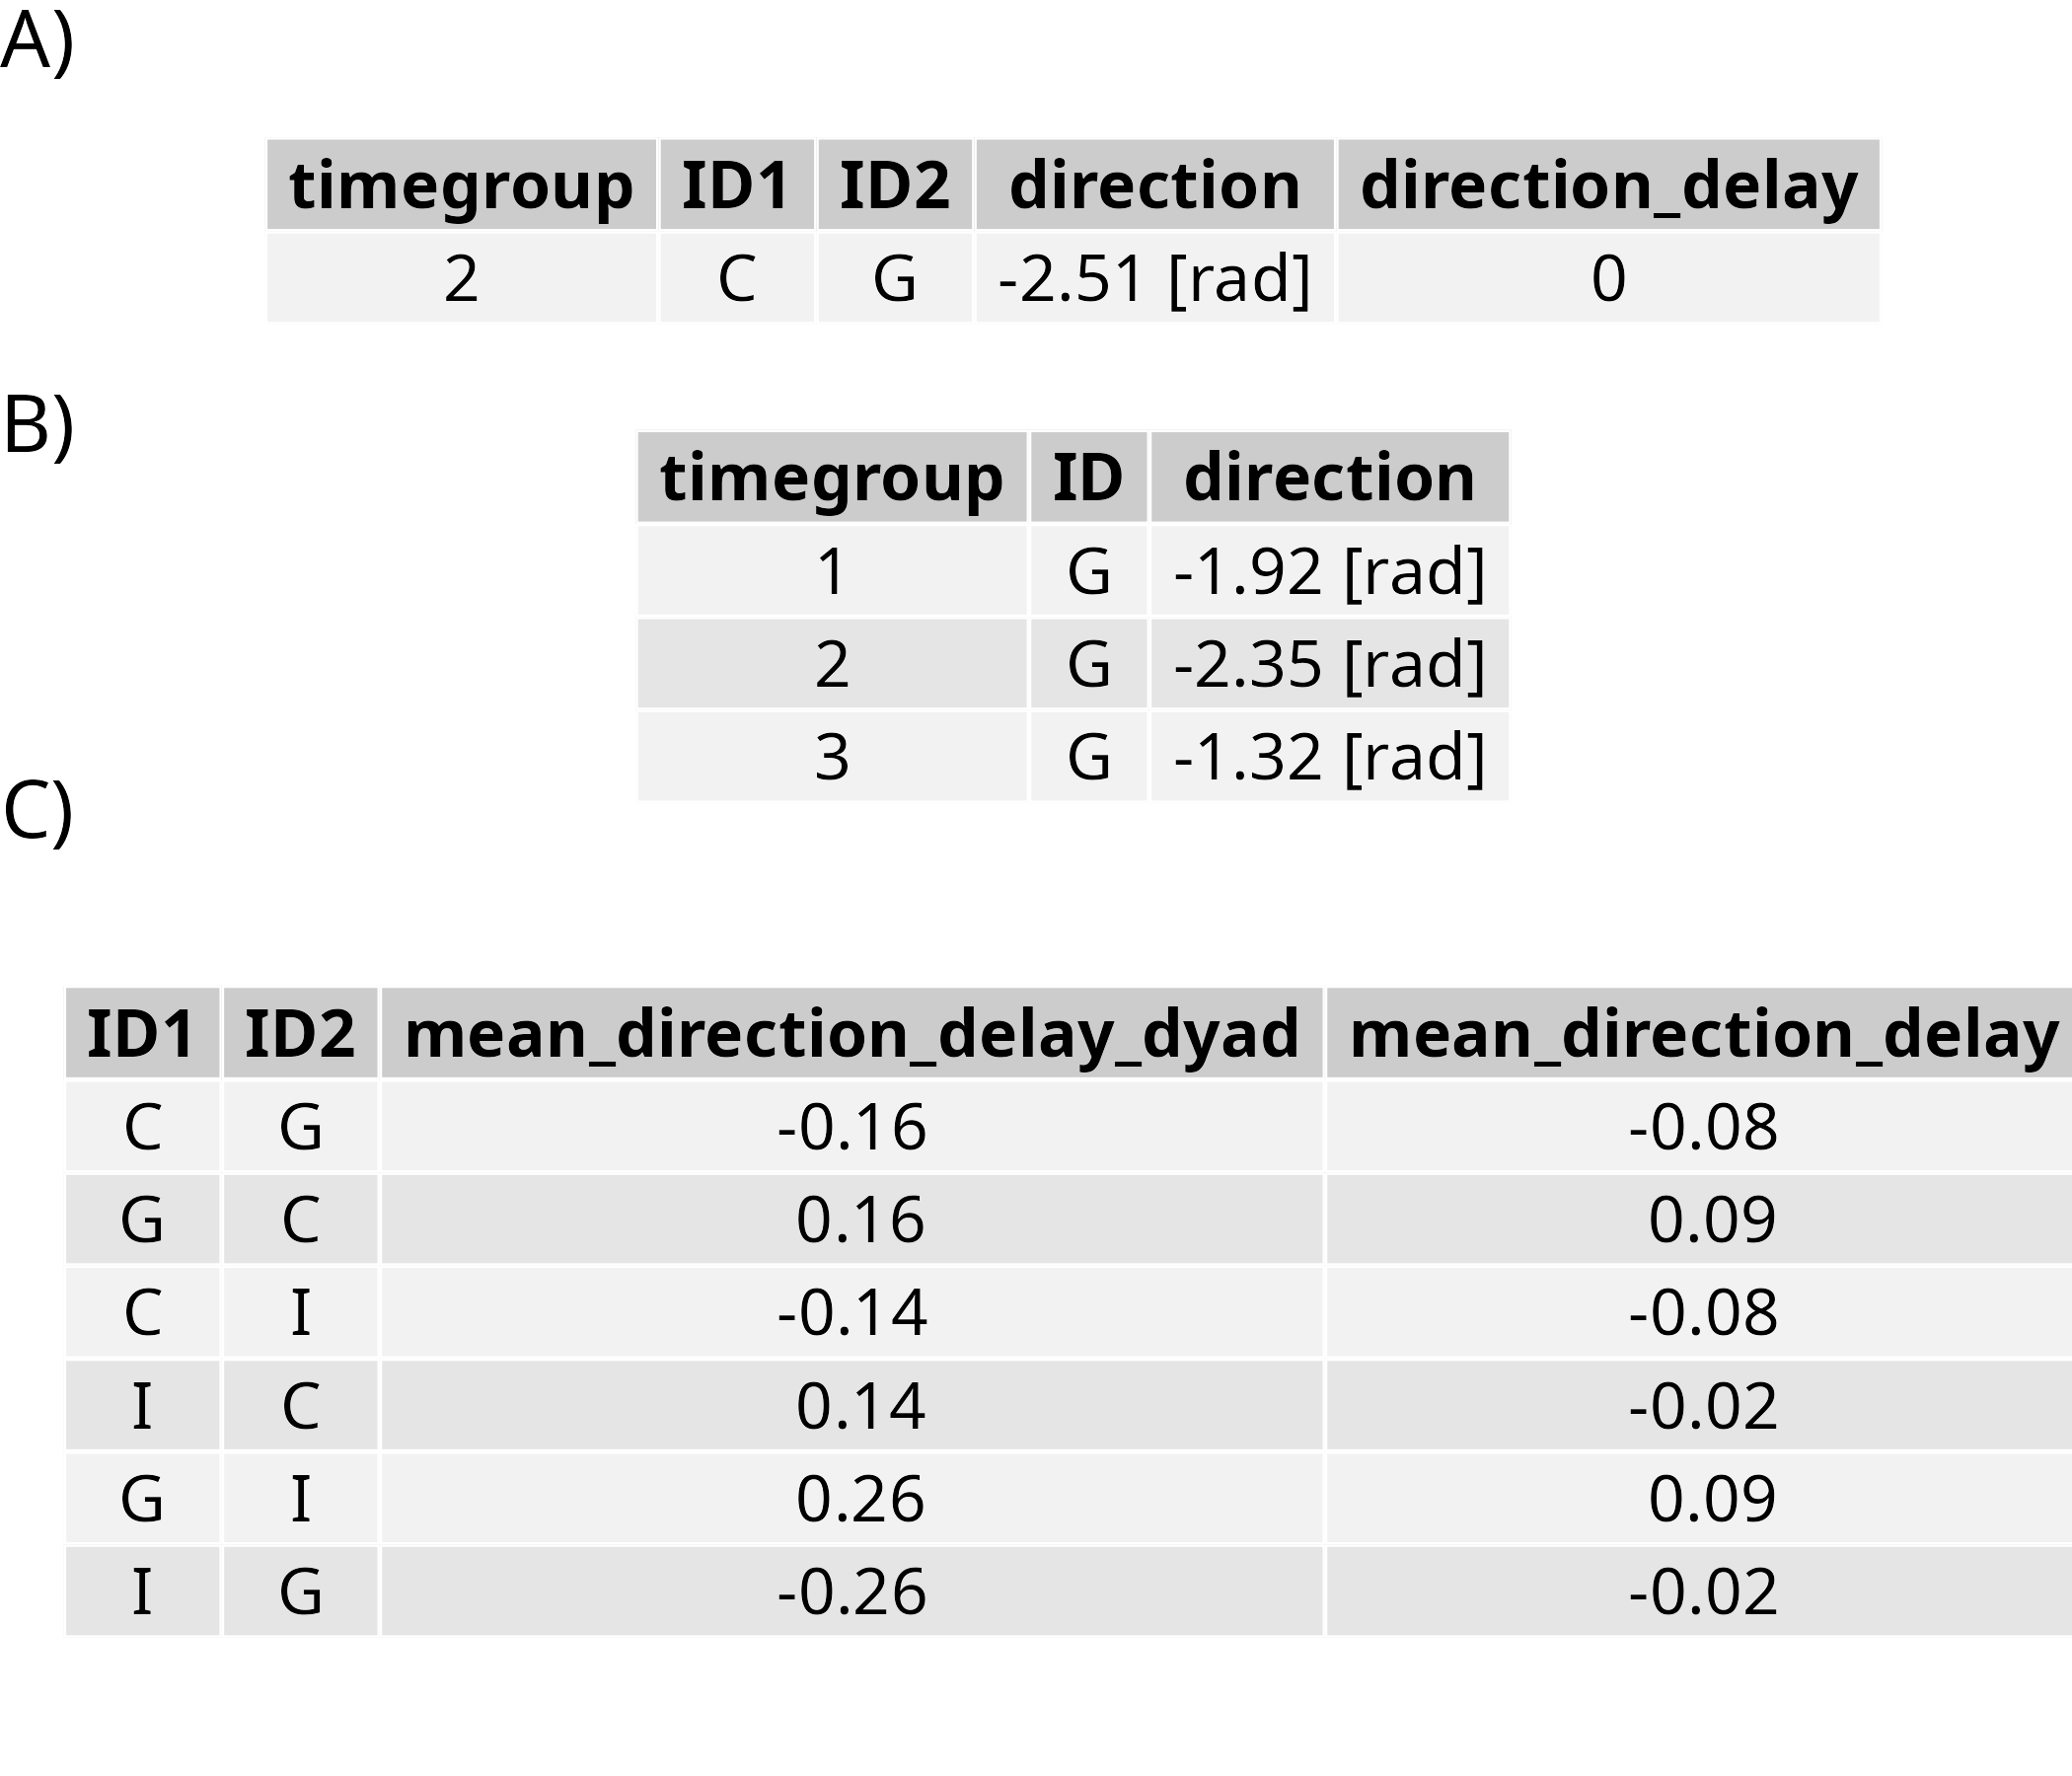

In [ ]:
library(spatsoc)

library(data.table)

DT <- fread(system.file("extdata", "DT.csv", package = "spatsoc"))

The code for producing the scoping review results, figures, tables and manuscript was developed as a reproducible pipeline with the R package {targets} \[@Landau_2021b\]. Figures and tables were constructed using {ggplot2} \[@Wickham_2016a\], {ggdist} \[@Kay_2025\], {patchwork} \[@Pedersen_2025\] and {tintytable} \[@Arel-Bundock_2025\]. The manuscript was produced using {quarto} \[@Allaire_2024\]. The {spatsoc} package gratefully depends on the R packages {adehabitatHR} \[@Calenge_2024\], {data.table} \[@Barrett_2025\], {igraph} \[@Csardi_2026\], {sf} \[@Pebesma_2018\], {lwgeom} \[@Pebesma_2025\], {CircStats} \[@Lund_2025\], {units} \[@Pebesma_2016\], and {rlang} \[@Henry_2026\].

# Acknowledgements

We thank Edzer Pebesma and Dewey Dunnington for support with bug reports and feature requests for the {sf}, {s2} and {lwgeom} packages related to the development of this new functionality in {spatsoc}. We thank Martin Leclerc, Rick Heeres and Shane Frank for testing the package’s new functionality ahead of its release. We thank members of the Wildlife Evolutionary Ecology Lab for their comments on previous versions of this manuscript. We thank the rOpenSci organisation including staff, editors, reviewers and contributors for their continued efforts to foster a community around open data, software and reproducibility.

# References

# Supplement: Scoping review methods

In [ ]:
targets::tar_source('R')

tar_load(review)
tar_load(geocoded)
tar_load(taxized)
tar_load(software_meta)

tar_load(counted)
count_code_avail <- counted$count_code_avail
count_prog_lang <- counted$count_prog_lang
count_software <- counted$count_software
count_metric <- counted$count_metric
count_dom_metric <- counted$count_dom_metric

We conducted a scoping review to identify metrics used in ecology studies for measuring dyadic interactions, dominance hierarchies and leadership patterns. We focused on metrics applicable to spatiotemporal data such as GPS telemetry. We used two databases of academic literature: Web of Science and Scopus. We established a test list of nine benchmark papers (Supplement A: Table 1) that were relevant to our objectives and verified that each paper was indexed in our selected databases. We used an iterative search method to fine-tune search terms measuring the total number of papers returned and sensitivity of the search. Sensitivity is defined as the proportion of potentially relevant papers returned from the search estimated using the number benchmark papers returned from the test list \[4.2.7 @CollaborationforEnvironmentalEvidence_2022\]. Search terms were established in four categories: topic, population, method and exclusion. Topic included terms associated with dyadic interactions, dominance hierarchies and leadership patterns. Population included terms associated with animals, wildlife and ecology. Method included terms associated with data collection and data types. Finally, a list of exclusion terms were used to remove clearly irrelevant papers. Each category of terms were combined with OR operators and all three categories of terms were combined with AND operators. The set of papers used in further steps was the combination of the last iteration of search terms applied to both of the Web of Science (using the “TS” field) and Scopus (using the “TITLE-ABS-KEY” field) databases. Only articles between 1980-2023 were included using the PY (Web of Science) or PUBYEAR (Scopus) fields. The resulting set of references were imported into Covidence \[@VeritasHealthInnovation_2025\] for deduplication, title and abstract screening, full text screening, and data extraction.

Before screening, articles were marked as duplicates using Covidence and manual screening. Covidence detected 799 duplicates based on title, year, volume, and authors, and manual screening identified an additional 128 duplicates.

Articles were screened out based on the following criteria:

-   Study does not describe dyadic or group metric related to leadership or dominance (eg. @Papageorgiou_2020)
-   Study describes metric that is not applicable to spatiotemporal data (eg. @Allanic_2020 used focal observations and video recordings)
-   Study does not describe metric beyond static interaction (eg. @Carter_2013 used home range or spatial overlap)
-   Study does not describe metric beyond group size (eg. @delMarDelgado_2021)
-   Study full text is not available in English (eg. @Bernard_2002)
-   Study is not a thesis
-   Study is not a book chapter (eg. @Bernstein_2019)

Despite a focus on animal ecology, some studies were discussed movement data more generically or, alternatively, specifically focused on human or robotic movement data (eg. @Long_2022). These studies were retained when the metrics described were deemed applicable to animal spatiotemporal movement data. Studies using mathematical models or simulations were largely beyond the scope of this review but studies were retained when the parameters used as inputs could be applied to spatial temporal data (eg. @Long_2015). Review studies were read for building the scope of the introduction and discussion but not included in data extraction unless they explicitly discussed dyadic measures (eg. @King_2018).

The goals of data extraction were to record the breadth of dyadic social and dominance metrics applicable to spatiotemporal data, and the degree of code availability. General information about each study was recorded including the type of study (empirical, simulation, algorithm, model, or review), study species and study region. Dyadic social metrics for each study were listed including citations and interpretation for each metric used and data input required. Dominance metrics derived from spatiotemporal data were listed including citations and interpretation. Code availability was described including location of code (eg. Zenodo, or GitHub), programming languages and software packages used.

Metrics identified were aggregated using a manual process to identify synonymous terms. This aggregation process was required due to variability in defining metrics during data extraction, as well as differences between authors in describing metrics (eg. distance to group “center”, “centroid”, or “center of mass”). Each study was geocoded using the {tidygeocoder} package \[@Cambon_2021\] and species were parsed using the {rgnparser} package \[@Chamberlain_2023\] which provides the GNparser \[@Mozzherin_2026\] functionality in R. We calculated frequency of data extracted for each categorical field including programming language, software package, analysis code availability, geographic region, study species and metric used. For many fields, authors did not provide sufficient to determine how metrics were calculated, eg. not including the programming language or software package used. In all cases, counts are presented as an overall frequency including papers with missing fields.

In [ ]:
data.table::fread('data/form.csv') |>
  tinytable::tt() |>
  style_tt(align = 'l')

Category,Field
General,Covidence #
,Study ID
,Title
Study information,"Type of study (Empirical, simulation, algorithm, model, review, other)"
,Species
,Region
Dyadic social metrics,Metric used or described
,Software package(s) used
,Citation for metric if not introduced in this paper
,Interpretation


In [ ]:
targets::tar_read(benchmark_papers) |>
  tinytable::tt() |>
  style_tt(align = 'l')

Citation,Indexed in WoS
"Nagy, Máté, Zsuzsa Ákos, Dora Biro, and Tamás Vicsek. 2010. “Hierarchical Group Dynamics in Pigeon Flocks.” _Nature_ 464 (7290): 890–93. [https://doi.org/10.1038/nature08891](https://doi.org/10.1038/nature08891).",TRUE
"Strandburg-Peshkin, Ariana, Damien R. Farine, Iain D. Couzin, and Margaret C. Crofoot. 2015. “Shared Decision-Making Drives Collective Movement in Wild Baboons.” _Science_ 348 (6241): 1358–61.",TRUE
"Merkle, J.A., M. Sigaud, and D. Fortin. 2015. “To Follow or Not? How Animals in Fusion–Fission Societies Handle Conflicting Information during Group Decision-Making.” _Ecology Letters_ 18 (8): 799–806.",TRUE
"Andersson, Mattias, Joachim Gudmundsson, Patrick Laube, and Thomas Wolle. 2007. “Reporting Leadership Patterns among Trajectories.” In _Proceedings of the 2007 ACM Symposium on Applied Computing_, 3–7. SAC ’07. New York, NY, USA: Association for Computing Machinery. [https://doi.org/10.1145/1244002.1244004](https://doi.org/10.1145/1244002.1244004).",TRUE
"Flack, Andrea, Máté Nagy, Wolfgang Fiedler, Iain D. Couzin, and Martin Wikelski. 2018. “From Local Collective Behavior to Global Migratory Patterns in White Storks.” _Science_ 360 (6391): 911–14.",TRUE
"Bracken, A.M., C. Christensen, M.J. O’Riain, I. Fürtbauer, and A.J. King. 2022. “Flexible Group Cohesion and Coordination, but Robust Leader-Follower Roles, in a Wild Social Primate Using Urban Space.” _Proc. R. Soc. B Biol. Sci._ 289 (1967). [https://doi.org/10.1098/rspb.2021.2141](https://doi.org/10.1098/rspb.2021.2141).",TRUE
"Long, Jed A., Trisalyn A. Nelson, Stephen L. Webb, and Kenneth L. Gee. 2014. “A Critical Examination of Indices of Dynamic Interaction for Wildlife Telemetry Studies.” _Journal of Animal Ecology_ 83 (5): 1216–33. [https://doi.org/10.1111/1365-2656.12198](https://doi.org/10.1111/1365-2656.12198).",TRUE
"Dodge, Somayeh, Robert Weibel, and Anna-Katharina Lautenschütz. 2008. “Towards a Taxonomy of Movement Patterns.” _Information Visualization_ 7 (3–4): 240–52. [https://doi.org/10.1057/PALGRAVE.IVS.9500182](https://doi.org/10.1057/PALGRAVE.IVS.9500182).",TRUE
"Laube, Patrick, Stephan Imfeld, and Robert Weibel. 2005. “Discovering Relative Motion Patterns in Groups of Moving Point Objects.” _International Journal of Geographical Information Science_ 19 (6): 639–68. [https://doi.org/10.1080/13658810500105572](https://doi.org/10.1080/13658810500105572).",TRUE


In [ ]:
targets::tar_read(search_strings) |>
  tinytable::tt() |>
  style_tt(align = 'l')

Source,String
Web of Science,"TS=(""dominance hierarch*"" OR ""leadership"" OR ""dominance"" OR ""collective move*"" OR ""fusion-fission"" OR ""fission-fusion"" OR (""fission*"" AND ""fusion*"") OR (""producer*"" AND ""scrounger"") OR ""producer-scrounger"" OR ""leader-follower"" OR ""leader follower"" OR (""leader*"" AND ""follower*"") OR (""finder*"" AND ""joiner*"") OR ""group cohesion"" OR ""dynamic interaction"" OR ""leadership pattern*"" OR ""collective behav*"" OR ""spatiotemporal group*"" OR ""relative motion"" OR ""group dynamics"") AND TS=(""ecolog*"" OR ""animal*"" OR ""wildlife"") AND TS=((""spatial*"" AND ""network*"") OR ""track*"" OR ""gps"" OR ""telemetry"" OR ""PIT"" OR ""video"" OR ""RFID"" OR ""biotelem*"" OR ""spatiotemporal"" OR ""spatio-temporal"" OR ""GPS"" OR ""movement pattern*"") NOT TS=(""human group*"" OR ""robot*"" OR ""genetic algorithm"" OR ""cell movement"" OR ""cellular"" OR ""sport*"" OR ""team sport*"" OR ""task force"" OR ""food web*"" OR ""host plant*"" OR ""fossil"" OR ""urbanism"" OR ""psychiatry"" OR ""bile"") AND PY=(1980-2023)"
Scopus,"TITLE-ABS-KEY (""dominance hierarch*"" OR ""leadership"" OR ""dominance"" OR ""collective move*"" OR ""fusion-fission"" OR ""fission-fusion"" OR (""fission*"" AND ""fusion*"") OR (""producer*"" AND ""scrounger"") OR ""producer-scrounger"" OR ""leader-follower"" OR ""leader follower"" OR (""leader*"" AND ""follower*"") OR (""finder*"" AND ""joiner*"") OR ""group cohesion"" OR ""dynamic interaction"" OR ""leadership pattern*"" OR ""collective behav*"" OR ""spatiotemporal group*"" OR ""relative motion"" OR ""group dynamics"") AND TITLE-ABS-KEY (""ecolog*"" OR ""animal*"" OR ""wildlife"") AND TITLE-ABS-KEY ((""spatial*"" AND ""network*"") OR ""track*"" OR ""gps"" OR ""telemetry"" OR ""PIT"" OR ""video"" OR ""RFID"" OR ""biotelem*"" OR ""spatiotemporal"" OR ""spatio-temporal"" OR ""GPS"" OR ""movement pattern*"") AND NOT TITLE-ABS-KEY (""human group*"" OR ""robot*"" OR ""genetic algorithm"" OR ""cell movement"" OR ""cellular"" OR ""sport*"" OR ""team sport*"" OR ""task force"" OR ""food web*"" OR ""host plant*"" OR ""fossil"" OR ""urbanism"" OR ""psychiatry"" OR ""bile"") AND PUBYEAR > 1980"


# Supplement: Scoping review results

In [ ]:
targets::tar_source('R')

tar_load(review)
tar_load(geocoded)
tar_load(taxized)
tar_load(software_meta)

tar_load(counted)
count_code_avail <- counted$count_code_avail
count_prog_lang <- counted$count_prog_lang
count_software <- counted$count_software
count_metric <- counted$count_metric
count_dom_metric <- counted$count_dom_metric

## Results

PRISMA

-   3870 references imported for screening as 3870 studies
    -   128 duplicates identified manually
    -   799 duplicates identified by Covidence
-   2943 studies screened against title and abstract
    -   2527 studies excluded
-   416 studies assessed for full-text eligibility
    -   275 studies excluded
        -   184 Does not discuss dyadic measure
        -   86 Metric not applicable to spatiotemporal data
        -   2 Book chapter
        -   2 Full text not in English
        -   1 Thesis
    -   0 studies ongoing
    -   0 studies awaiting classification
-   141 studies included

In [ ]:
count_code_avail[, .N, analysis_code_availability][
  order(-N),
  .(
    `Code availability` = analysis_code_availability,
    N = paste_n_percent(N)
  )
] |>
  tt()

Code availability,N
No,114 (81%)
Yes,26 (19%)


In [ ]:
list_prog <- count_prog_lang[,
  uniqueN(covidence_number),
  .(prog = !is.na(programming_language))
]
unique_prog_lang <- count_prog_lang[,
  uniqueN(programming_language),
  covidence_number
]

Out of 141 articles, 52 did not list a programming language or GUI program. Of the 89 that did, 21 articles listed more than one programming language or GUI program, therefore the total count below will be greater than the number of articles.

In [ ]:
count_prog_lang[, .N, programming_language][
  order(-N),
  .(
    `Programming language` = programming_language,
    N = paste_n_percent(N)
  )
] |>
  tt()

Programming language,N
R,62 (36.26%)
NA,52 (30.41%)
MATLAB,15 (8.77%)
Python,6 (3.51%)
CUDA,4 (2.34%)
Ucinet,3 (1.75%)
Perl,3 (1.75%)
C++,3 (1.75%)
NetLogo,2 (1.17%)
SPSS,2 (1.17%)


Out of 140 articles, 112 did not list a software package. Of the 28 that did, 14 articles listed more than one software package , therefore the total count below will be greater than the number of articles.

In [ ]:
count_software[, .N, software_package_s_used][
  order(-N),
  .(
    `Software package used` = software_package_s_used,
    N = paste_n_percent(N)
  )
] |>
  tt()

Software package used,N
NA,112 (66.67%)
wildlifeDI,9 (5.36%)
geosphere,3 (1.79%)
adehabitat,2 (1.19%)
moveVis,2 (1.19%)
ctmm,2 (1.19%)
CircStats,2 (1.19%)
corrMove,2 (1.19%)
adehabitatHR,2 (1.19%)
numpy,2 (1.19%)


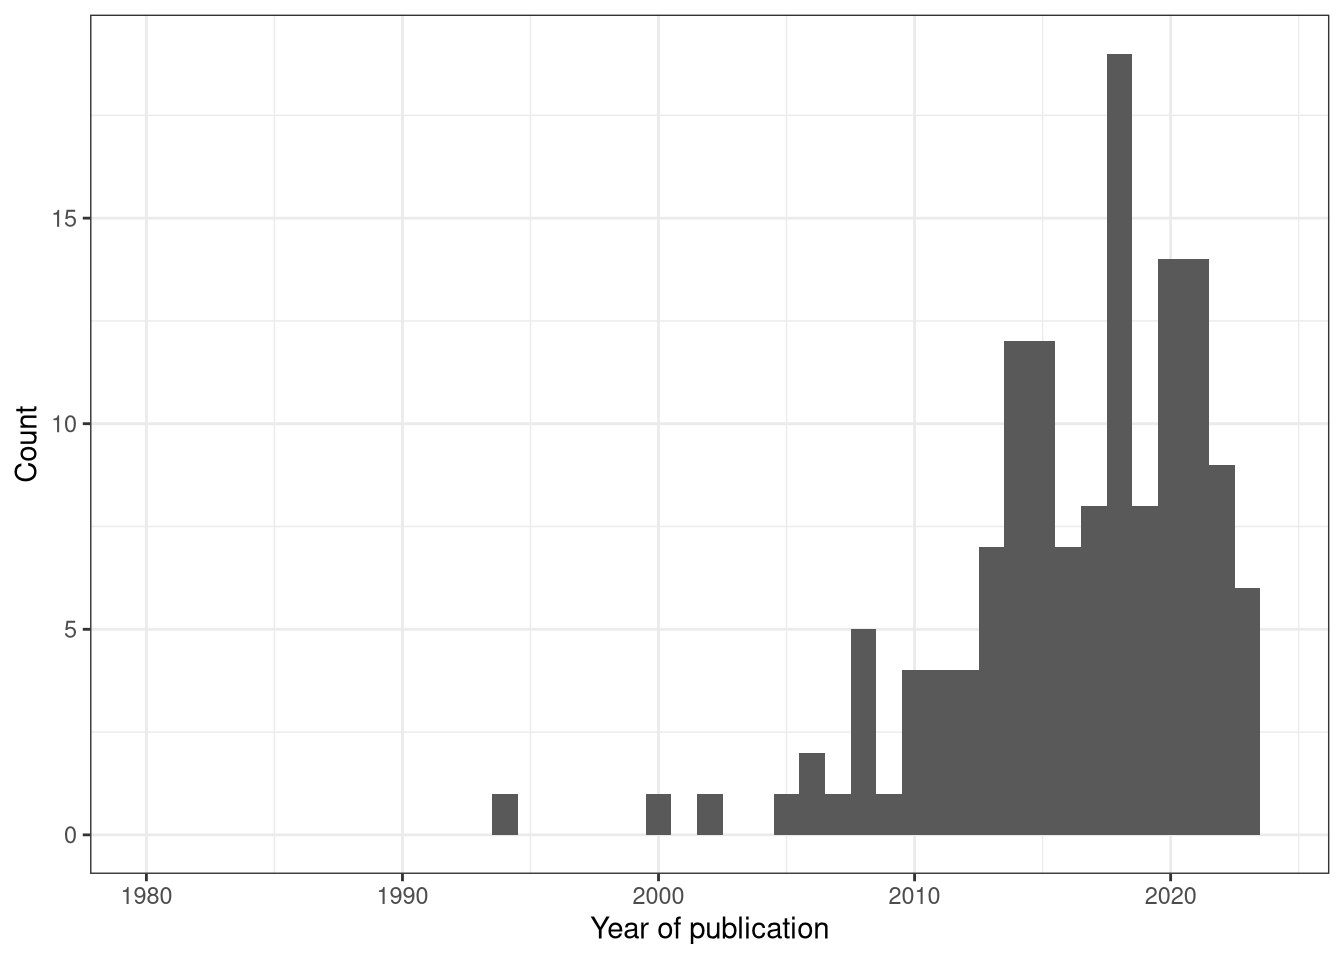

In [ ]:
ggplot(review) +
  geom_histogram(aes(yr), binwidth = 1) +
  labs(x = 'Year of publication', y = 'Count') +
  coord_cartesian(xlim = c(1980, 2024)) +
  theme_bw()

Warning in CPL_crs_from_input(x): GDAL Message 1: EPSG:54030 is not a valid CRS
code, but ESRI:54030 is. Assuming ESRI:54030 was meant

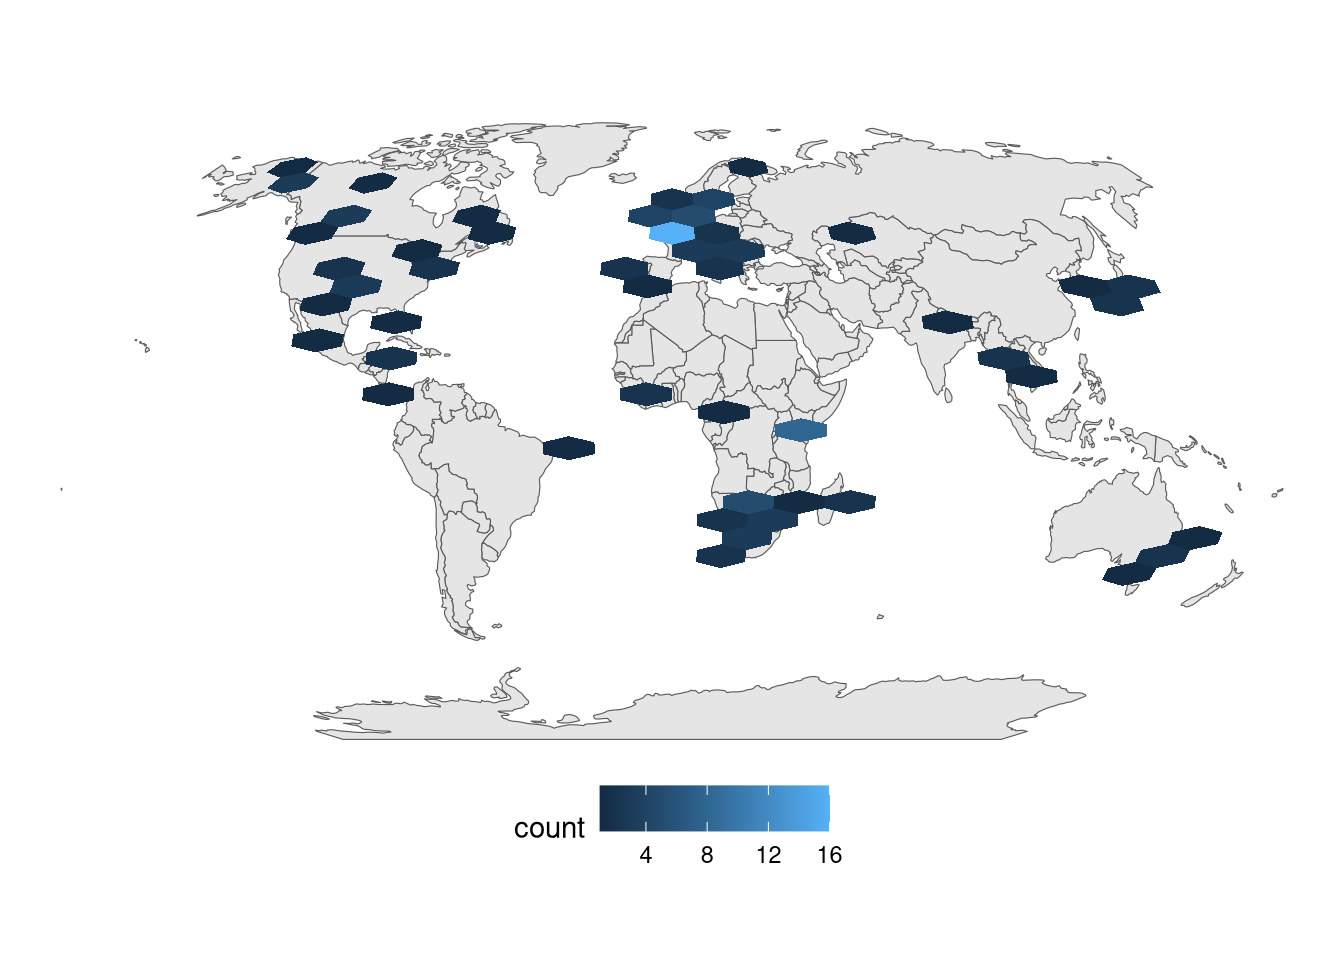

In [ ]:
countries <- ne_countries()

ggplot() +
  geom_sf(data = countries) +
  geom_hex(
    aes(long, lat),
    alpha = 1,
    bins = 20,
    data = geocoded[!is.na(long)]
  ) +
  coord_sf(crs = 54030, default_crs = 4326) +
  theme_void() +
  theme(legend.position = 'bottom')

In [ ]:
taxized[, .N, parsed_species][
  order(-N),
  .(
    Species = parsed_species,
    N = paste_n_percent(N)
  )
] |>
  tt() |>
  style_tt(j = "Species", italic = TRUE)

Species,N
Columba livia,9 (7.09%)
Danio rerio,6 (4.72%)
Rangifer tarandus,6 (4.72%)
Gasterosteus aculeatus,5 (3.94%)
Papio anubis,5 (3.94%)
Poecilia reticulata,5 (3.94%)
Macaca fuscata,4 (3.15%)
Ovis aries,4 (3.15%)
Bos taurus,3 (2.36%)
Ateles geoffroy,3 (2.36%)


In [ ]:
count_metric[, .N, metric_agg][
  order(-N),
  .(
    `Metric` = metric_agg,
    N = paste_n_percent(N)
  )
] |>
  tt()

Metric,N
interindividual distance,61 (14.73%)
nearest neighbour distance,19 (4.59%)
directional correlation delay,18 (4.35%)
speed,17 (4.11%)
position within group,16 (3.86%)
direction,15 (3.62%)
zones,15 (3.62%)
distance to group centroid,14 (3.38%)
fission fusion,13 (3.14%)
directional alignment,9 (2.17%)


In [ ]:
count_dom_metric[, .N, dominance_metric_agg][
  order(-N),
  .(
    `Dominance metric` = dominance_metric_agg,
    N = paste_n_percent(N)
  )
] |>
  tt()

Dominance metric,N
NA,112 (77.24%)
focal observations,14 (9.66%)
direction correlation delay,5 (3.45%)
fleeing events,2 (1.38%)
survey,2 (1.38%)
approach-avoidance events,2 (1.38%)
egalitarian leadership index,1 (0.69%)
movement initiations,1 (0.69%)
proportion of paired flights led,1 (0.69%)
spatially constrained trend-setter,1 (0.69%)


In [ ]:
review[definition_category == 'group', .(study_id, definition)] |>
  tt()

study_id,definition
Quaglietta 2014,interaction if within 100 m and 1 hour
Mielke 2020,group defined as all individuals within visual contact of focal individual
Leighty 2008,proximity defined as 8 m; approach/avoidance after event defined as changes in interindividual distance after an event
Hansen 2015,fish considered isolated if not within three body lengths of any other fish; group defined by within three body lengths
Bista 2022,"temporal threshold 2 hour, distance threshold 100 m"
Pinacho-Guendulain 2017,group using 30 m chain rule
Lemasson 2014,group when within 5 body lengths
Inoue 2019,proximity defined as two body lengths away


In [ ]:
review[definition_category == 'leadership', .(study_id, definition)] |>
  tt()

study_id,definition
Rahman 2020,leadership as tendency to be at the front of the group
Quera 2023,"following Krause et al. (2000) and Collignon et al. (2019), the authors define a motion leader as an individual who initiates movement towards a certain direction and is followed by other group members"
Andrienko 2013,leader is an object that moves in front of others; trend setter is an object whose movements are copied by others
Amornbunchornvej 2018,following relation is where two individuals perform the same sequence of actions with some fixed delay; initiator is individual who first performs a sequence of actions and all other individuals follow
Kano 2021,leader from directional correlation delay
Pettit 2013,leadership based on directional correlation delay; leadership also based on tendency to use route taken on solo flight
Pérez-Barbería 2018,leadership is ranked position along front-back axis
Laube 2005,leadership extends flock with constance over previous time steps
Milner 2021,leader is animal that is dominant to at least one and subordinate to none
Strandburg-Peshkin 2018,an individual leads if it has repeated influence either directly or hierarchically on the behaviour of others


In [ ]:
review[definition_category == 'fission fusion', .(study_id, definition)] |>
  tt()

study_id,definition
Baden 2016,NA
Aguilar-Melo 2018,fission when gte 1 were not observed with a group for 2 consecutive scans; fusion when gte 1 who were previously not observed with group are observed with group for 2 consecutive scans
Barocas 2016,fission and fusion defined as joining and leaving group in subsequent observations
Haydon 2008,fusion where solitary to grouped and fission where grouped to solitary
Fortin 2009,group/fusion when within 100 m; fission when two or more consecutive locations separated by > 100 m
Body 2015,fusion gte 2 groups merging into one; fission one group splitting into gte 2
DellaLibera 2023,"define a fission and fusion event if one or more individuals left or joined the group, respectively. in the rare cases of missing data, missing individuals are not considered as having changed group membership, and individual ‘disappearances’ and ‘reappearances’ in the dataset are not considered as fission–fusion events"
Wielgus 2020,group where simultaneously within 1 km or >= 1 km for <= 2 hr; fusion where together then different by one time step; fission reverse
Nishikawa 2014,converged when IID less than 20 m; separated when IID greater than 20 m; converged and separated synonymous with fission fusion
Krueger 2014,NA


# Supplement: Selected metrics

In [ ]:
targets::tar_source('R')
tar_load(taxized)
tar_load(geocoded)
tar_load(review)
tar_load(counted)
count_code_avail <- counted$count_code_avail
count_prog_lang <- counted$count_prog_lang
count_software <- counted$count_software
count_metric <- counted$count_metric

## Selected metrics

The following metrics were not selected due to their availability in existing R packages:

-   {wildlifeDI}: DI, Don, Prox, Lixn, Cs, DI in direction, DI in displacement, HAI, IAB, Cr, Ca
-   {corrMove}: diffusive movement correlation, drift movement correlation, overall component movement correlation
-   {changepoint}: change point analysis

The following metrics were not selected due to their availability in code availability accompanying publications:

-   mFLICA provided in code accompanying @Amornbunchornvej_2018 and R package {mFLICA} \[@Amornbunchornvej_2021\]

The follow metrics were not selected due to the expected input data differing from existing {spatsoc} functions (XYT):

-   metrics relating to posture

The selected metrics are listed in \[@tbl-new-functions\]. All existing functions in {spatsoc} are listed below in \[@tbl-all-functions\].

In [ ]:
functions <- fread('data/spatsoc-functions.tsv')
functions[, .(Function, Description, Category)] |>
  tt() |>
  group_tt(i = functions$Family) |>
  style_tt(align = 'l')

Function,Description,Category
Spatial interface,Spatial interface,Spatial interface
get_geometry(),Setup data for geometry interface,New
Edge-list generation,Edge-list generation,Edge-list generation
edge_dist(),Distance based edge-lists,Existing
edge_nn(),Nearest neighbour based edge-lists,Existing
edge_delay(),Directional correlation delay based edge-lists,New
edge_alignment(),Directional alignment based edge-lists,New
edge_direction(),Direction based edge-lists,New
edge_zones(),Behavioural zones based edge-lists,New
Dyad,Dyad,Dyad


### Distance, direction and rank distance to group centroid

In [ ]:
to_grp_cent <- count_metric[
  metric_agg %in%
    c(
      'direction to group centroid',
      'distance to group centroid',
      'rank distance to group centroid',
      'group centroid'
    )
]

Our scoping review found 21 studies that used the group centroid, distance to group centroid, direction to group centroid, or rank distance to group centroid metrics, across 14 study species. 4 studies had code available. The {swaRm} package provides functionality to calculate the group centroid and the distance to the group centroid. At the time when the scoping review was conducted, to the best of our knowledge, there were no R packages that provide the rank to distance to group centroid metric.

### Polarization, directional alignment and interindividual direction

In [ ]:
align <- count_metric[
  metric_agg %in%
    c(
      'polarization',
      'directional alignment',
      'interindividual direction',
      'nearest neighbour direction'
    )
]

Our scoping review found 20 studies that used the polarization, directional alignment or interindividual direction metrics, across 11 study species. 4 studies had code available. The {CircStats} package provides functionality to calculate the polarization order parameter, as well as the {swaRm} package. At the time when the scoping review was conducted, to the best of our knowledge, there were no R packages that provide the directional alignment or interindividual direction metrics.

### Behavioural zones

In [ ]:
zone <- count_metric[metric_agg %in% c('zones')]

Our scoping review found 13 studies that used the behavioural zones metric, across 9 study species. 4 studies had code available. At the time when the scoping review was conducted, to the best of our knowledge, there were no R packages that provide the behavioural zones metric.

### Position within group, rank position within group, distance and direction to leader

In [ ]:
pos_wi <- count_metric[
  metric_agg %in%
    c(
      'position within group',
      'rank position within group',
      'distance to leader',
      'direction to leader'
    )
]

Our scoping review found 18 studies that used the position within group, rank position within group, distance to leader, or direction to leader metrics across 14 study species. Only 1 studies had code available. At the time when the scoping review was conducted, to the best of our knowledge, there were no R packages that provide these metrics.

### Directional correlation delay

In [ ]:
dirr_del <- count_metric[metric_agg == 'directional correlation delay']

Our scoping review found 17 studies that used the directional correlation delay metric, across 12 study species. Only 1 study had code available using a combination of MATLAB (closed source), CUDA (closed source), and Python (open source). At the time when the scoping review was conducted, to the best of our knowledge, there were no R packages that provide this metric.